In [1]:
from numpy import *
import MDAnalysis as mda
import MDAnalysis.analysis.distances
from pylab import *
style.use('seaborn-poster')
import glob
import scipy.stats
import seaborn as sns
import pandas as pd
threeColor=["#FE6100","#332288","#882255"]
colourScheme = threeColor
system_names = ["rhT5A","T5A","T5AR332P"]

system_labels = [r"rhTRIM5$\alpha$",r"huTRIM5$\alpha$",r"huTRIM5$\alpha^{R332P}$"]


EQPOINT = 0

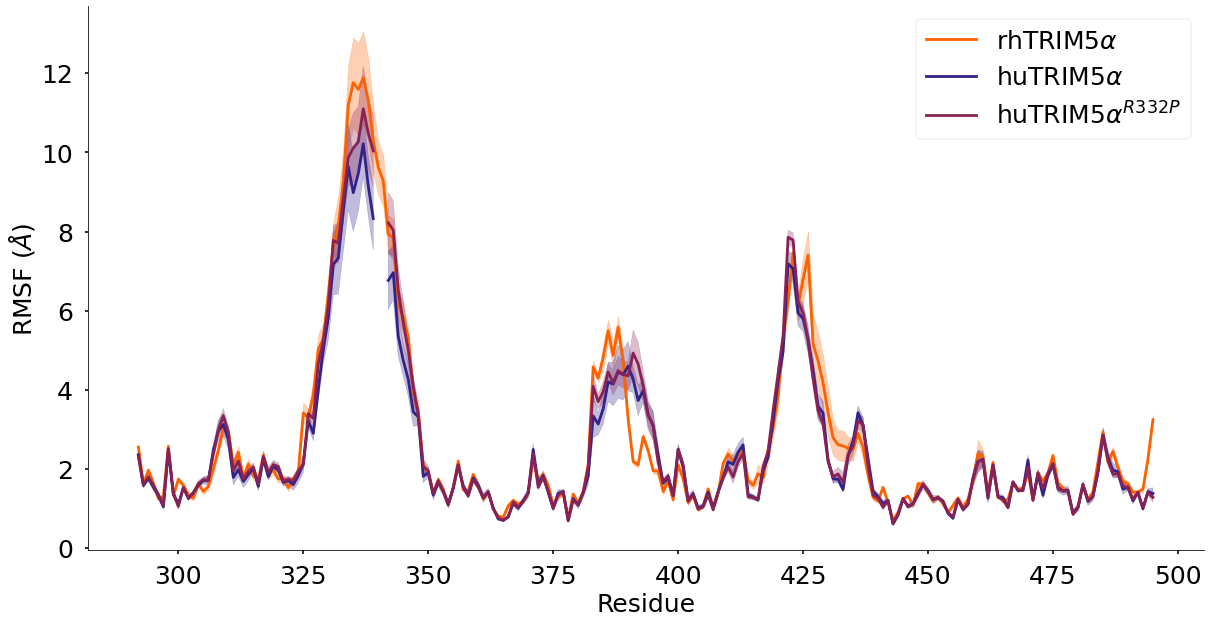

In [2]:
allrmsfs_residue=[]
for i in range(len(system_names)):
    allrmsfs_residue.append(load(system_names[i]+"rmsf.npy"))
    
#allrmsfs_residue=load("allrmsfs_residue.npy",allow_pickle = True)
            
    
system_avg=[]
system_sem=[]

for i in range(len(allrmsfs_residue)):
    system_avg.append(mean(allrmsfs_residue[i],axis = 0))
    system_sem.append(scipy.stats.sem(allrmsfs_residue[i],axis = 0))
    
def insertMyNans(huArray,indices):
    huList = list(huArray)
    # Note, index list should be in descending order, otherwise there will be problems 
    # (since the index of later indexes will increase every time you make an insertion)
    for i in range(len(indices)):
        huList.insert(indices[i],nan)
    return array(huList)
#
for i in range(1,len(system_avg)):
    system_avg[i] = insertMyNans(system_avg[i],indices = [338-290,338-290])
    system_sem[i] = insertMyNans(system_sem[i],indices = [338-290,338-290])
    
    
    
rhresids = arange(292,496)
huresids = arange(290,492)#systems[1][0].select_atoms("protein").residues.resids


mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False



figure(figsize = (20,10))
plot(rhresids,system_avg[0],color = colourScheme[0],label = system_labels[0])
plot(rhresids,system_avg[1],color = colourScheme[1],label = system_labels[1])
plot(rhresids,system_avg[2],color = colourScheme[2],label = system_labels[2])
    
fill_between(rhresids, system_avg[0] - system_sem[0],system_avg[0] + system_sem[0],color = colourScheme[0],alpha = 0.3)
fill_between(rhresids, system_avg[1] - system_sem[1],system_avg[1] + system_sem[1],color = colourScheme[1],alpha = 0.3)
fill_between(rhresids, system_avg[2] - system_sem[2],system_avg[2] + system_sem[2],color = colourScheme[2],alpha = 0.3)


xlabel("Residue",fontsize = 25)
ylabel("RMSF ($\AA$)",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

#xlim(400,440)    
    
    
    
    




C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

(0.0, 450.0)

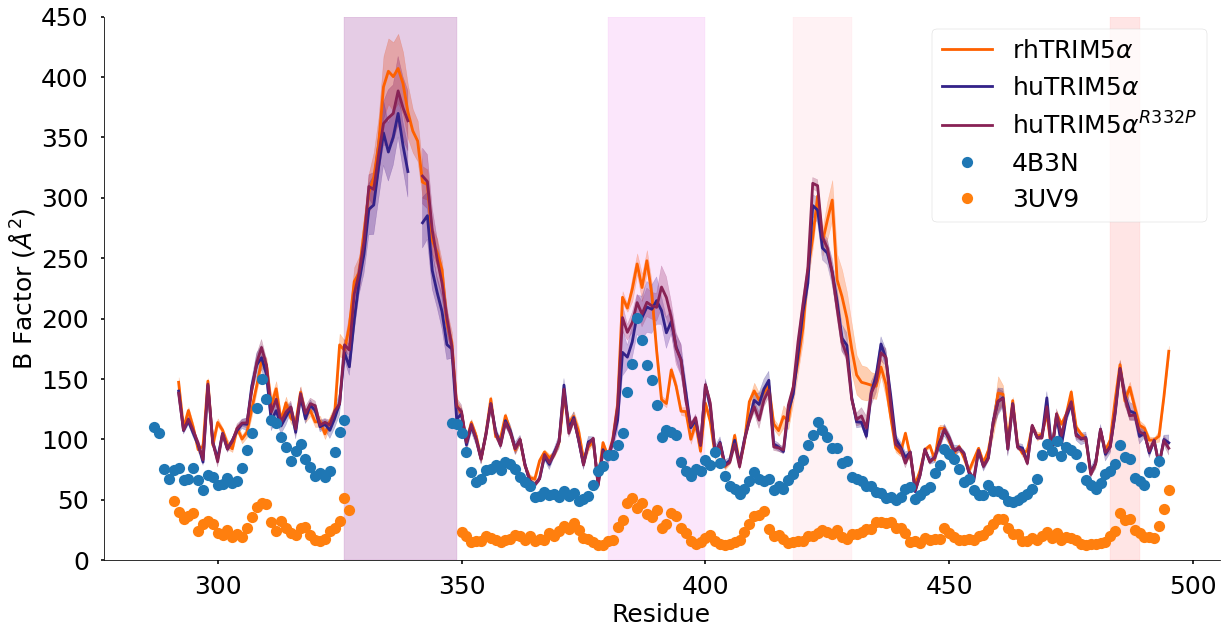

In [3]:
#pdb_3kb5 = mda.Universe("pdbs/crystals/3kb5.pdb")
#ca_3kb5_bfactors = pdb_3kb5.select_atoms("protein and name CA").bfactors

pdb_3uv9 = mda.Universe("pdbs/crystals/3uv9.pdb")
ca_3uv9_bfactors = pdb_3uv9.select_atoms("protein and name CA").tempfactors
#
#pdb_3zo0 = mda.Universe("pdbs/crystals/3zo0.pdb")
#ca_3zo0_bfactors = pdb_3zo0.select_atoms("protein and name CA").bfactors

pdb_4b3n = mda.Universe("pdbs/crystals/4b3n.pdb")
ca_4b3n_bfactors = pdb_4b3n.select_atoms("protein and name CA").tempfactors

#pdb_7jl4 = mda.Universe("pdbs/crystals/7jl4.pdb")
#ca_7jl4_bfactors = pdb_7jl4.select_atoms("protein and name CA").bfactors
#

#allrmsfs_residue=load("allrmsfs_residue.npy",allow_pickle = True)

allbfs_residue = []
for i in range(len(allrmsfs_residue)):
    sub=[]
    for j in range(len(allrmsfs_residue[i])):
        sub.append(list(array(allrmsfs_residue[i][j])**(2/3)*8*np.pi*np.pi))
    allbfs_residue.append(sub)
    
system_avg=[]
system_sem=[]

for i in range(len(allbfs_residue)):
    system_avg.append(mean(allbfs_residue[i],axis = 0))
    system_sem.append(scipy.stats.sem(allbfs_residue[i],axis = 0))
    
def insertMyNans(huArray,indices):
    huList = list(huArray)
    # Note, index list should be in descending order, otherwise there will be problems 
    # (since the index of later indexes will increase every time you make an insertion)
    for i in range(len(indices)):
        huList.insert(indices[i],nan)
    return array(huList)
#
for i in range(1,len(system_avg)):
    system_avg[i] = insertMyNans(system_avg[i],indices = [338-290,338-290])
    system_sem[i] = insertMyNans(system_sem[i],indices = [338-290,338-290])
    
    
    
#rhresids = arange(291,495)
huresids = arange(290,492)#systems[1][0].select_atoms("protein").residues.resids


mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False


figure(figsize = (20,10))
plot(rhresids,system_avg[0],color = colourScheme[0],label = system_labels[0])
plot(rhresids,system_avg[1],color = colourScheme[1],label = system_labels[1])
plot(rhresids,system_avg[2],color = colourScheme[2],label = system_labels[2])
    
fill_between(rhresids, system_avg[0] - system_sem[0],system_avg[0] + system_sem[0],color = colourScheme[0],alpha = 0.3)
fill_between(rhresids, system_avg[1] - system_sem[1],system_avg[1] + system_sem[1],color = colourScheme[1],alpha = 0.3)
fill_between(rhresids, system_avg[2] - system_sem[2],system_avg[2] + system_sem[2],color = colourScheme[2],alpha = 0.3)


plot(pdb_4b3n.select_atoms("protein").residues.resids-1000,ca_4b3n_bfactors,"o",label = "4B3N")
plot(pdb_3uv9.select_atoms("protein").residues.resids,ca_3uv9_bfactors,"o",label = "3UV9")


xlabel("Residue",fontsize = 25)
ylabel("B Factor ($\AA^2$)",fontsize = 25)#"",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

#axvline(440,alpha = 0.1)


axvspan(326,349,color = "purple", alpha = 0.2)
axvspan(380,400,color = "violet", alpha = 0.2)
axvspan(418,430,color = "pink", alpha = 0.2)
axvspan(483,489,color = "red", alpha = 0.1)

ylim(0,450)

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

(320.0, 440.0)

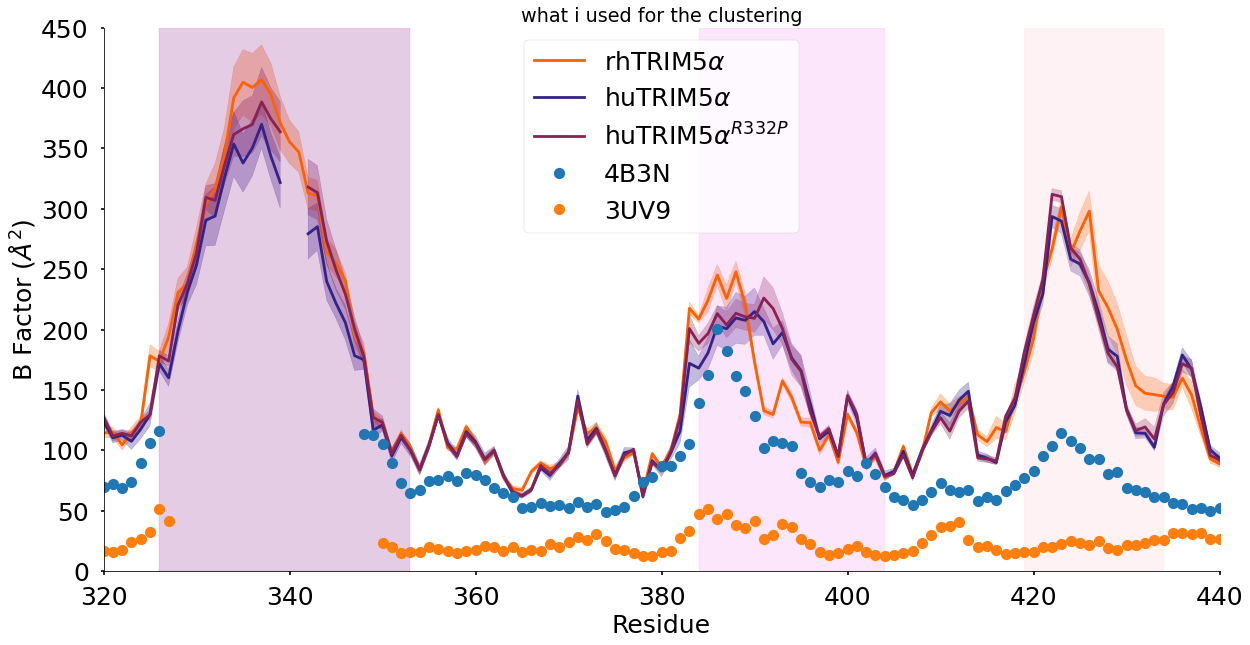

In [4]:
#pdb_3kb5 = mda.Universe("pdbs/crystals/3kb5.pdb")
#ca_3kb5_bfactors = pdb_3kb5.select_atoms("protein and name CA").bfactors

pdb_3uv9 = mda.Universe("pdbs/crystals/3uv9.pdb")
ca_3uv9_bfactors = pdb_3uv9.select_atoms("protein and name CA").tempfactors
#
#pdb_3zo0 = mda.Universe("pdbs/crystals/3zo0.pdb")
#ca_3zo0_bfactors = pdb_3zo0.select_atoms("protein and name CA").bfactors

pdb_4b3n = mda.Universe("pdbs/crystals/4b3n.pdb")
ca_4b3n_bfactors = pdb_4b3n.select_atoms("protein and name CA").tempfactors

#pdb_7jl4 = mda.Universe("pdbs/crystals/7jl4.pdb")
#ca_7jl4_bfactors = pdb_7jl4.select_atoms("protein and name CA").bfactors
#

#allrmsfs_residue=load("allrmsfs_residue.npy",allow_pickle = True)

allbfs_residue = []
for i in range(len(allrmsfs_residue)):
    sub=[]
    for j in range(len(allrmsfs_residue[i])):
        sub.append(list(array(allrmsfs_residue[i][j])**(2/3)*8*np.pi*np.pi))
    allbfs_residue.append(sub)
    
system_avg=[]
system_sem=[]

for i in range(len(allbfs_residue)):
    system_avg.append(mean(allbfs_residue[i],axis = 0))
    system_sem.append(scipy.stats.sem(allbfs_residue[i],axis = 0))
    
def insertMyNans(huArray,indices):
    huList = list(huArray)
    # Note, index list should be in descending order, otherwise there will be problems 
    # (since the index of later indexes will increase every time you make an insertion)
    for i in range(len(indices)):
        huList.insert(indices[i],nan)
    return array(huList)
#
for i in range(1,len(system_avg)):
    system_avg[i] = insertMyNans(system_avg[i],indices = [338-290,338-290])
    system_sem[i] = insertMyNans(system_sem[i],indices = [338-290,338-290])
    
    
    
#rhresids = arange(291,495)
huresids = arange(290,492)#systems[1][0].select_atoms("protein").residues.resids


mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False


figure(figsize = (20,10))
plot(rhresids,system_avg[0],color = colourScheme[0],label = system_labels[0])
plot(rhresids,system_avg[1],color = colourScheme[1],label = system_labels[1])
plot(rhresids,system_avg[2],color = colourScheme[2],label = system_labels[2])
    
fill_between(rhresids, system_avg[0] - system_sem[0],system_avg[0] + system_sem[0],color = colourScheme[0],alpha = 0.3)
fill_between(rhresids, system_avg[1] - system_sem[1],system_avg[1] + system_sem[1],color = colourScheme[1],alpha = 0.3)
fill_between(rhresids, system_avg[2] - system_sem[2],system_avg[2] + system_sem[2],color = colourScheme[2],alpha = 0.3)


plot(pdb_4b3n.select_atoms("protein").residues.resids-1000,ca_4b3n_bfactors,"o",label = "4B3N")
plot(pdb_3uv9.select_atoms("protein").residues.resids,ca_3uv9_bfactors,"o",label = "3UV9")


xlabel("Residue",fontsize = 25)
ylabel("B Factor ($\AA^2$)",fontsize = 25)#"",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)
title("what i used for the clustering")

#axvline(440,alpha = 0.1)


axvspan(326,353,color = "purple", alpha = 0.2)
axvspan(384,404,color = "violet", alpha = 0.2)
axvspan(419,434,color = "pink", alpha = 0.2)
#axvspan(483,489,color = "red", alpha = 0.1)

ylim(0,450)
xlim(320,440)

(0.0, 7.0)

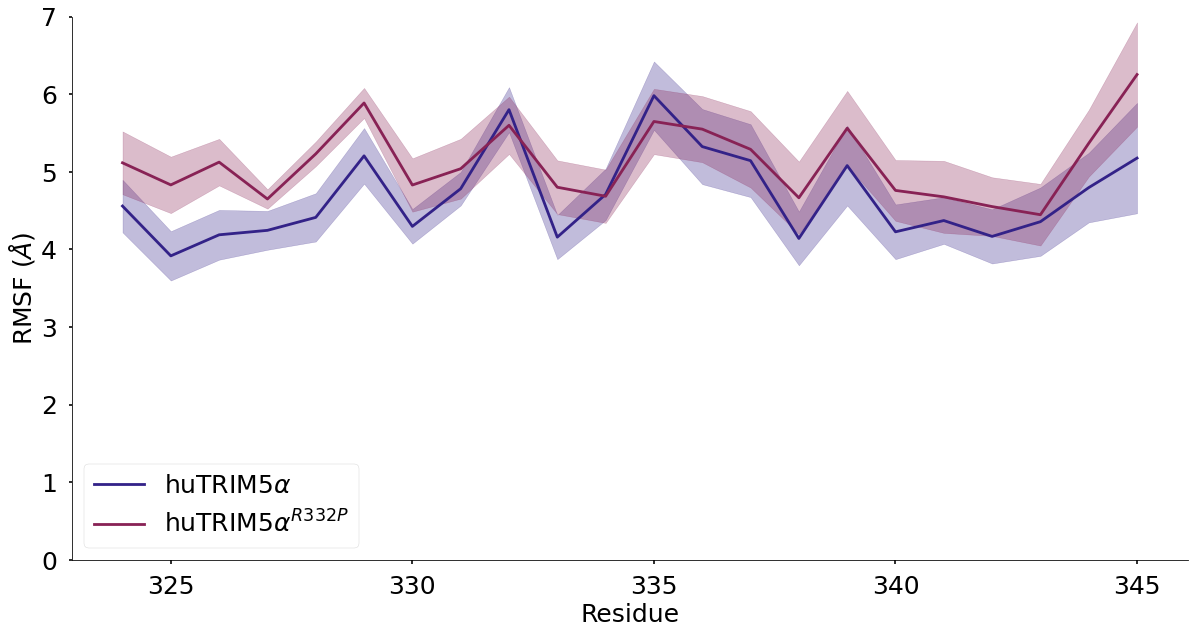

In [5]:
allrmsfs_residue=[]
for i in range(len(system_names)):
    allrmsfs_residue.append(load(system_names[i]+"rmsf-v1-only.npy"))
    
    #allrmsfs_residue=load("allrmsfs_residue.npy",allow_pickle = True)
            
    
system_avg=[]
system_sem=[]

for i in range(len(allrmsfs_residue)):
    system_avg.append(mean(allrmsfs_residue[i],axis = 0))
    system_sem.append(scipy.stats.sem(allrmsfs_residue[i],axis = 0))
    
#def insertMyNans(huArray,indices):
#    huList = list(huArray)
#    # Note, index list should be in descending order, otherwise there will be problems 
#    # (since the index of later indexes will increase every time you make an insertion)
#    for i in range(len(indices)):
#        huList.insert(indices[i],nan)
#    return array(huList)
#
#for i in range(1,len(system_avg)):
#    system_avg[i] = insertMyNans(system_avg[i],indices = [338-290,338-290])
#    system_sem[i] = insertMyNans(system_sem[i],indices = [338-290,338-290])
    
    
    
rhresids = arange(291,495)
huresids =huresids = arange(290,492)# systems[1][0].select_atoms("protein").residues.resids
figure(figsize = (20,10))
#plot(rhresids,system_avg[0],color = colourScheme[0],label = system_names[0])
plot(arange(324,346),system_avg[1],color = colourScheme[1],label = system_labels[1])
plot(arange(324,346),system_avg[2],color = colourScheme[2],label = system_labels[2])
    
#fill_between(arange(324,346), system_avg[0] - system_sem[0],system_avg[0] + system_sem[0],color = colourScheme[0],alpha = 0.3)
fill_between(arange(324,346), system_avg[1] - system_sem[1],system_avg[1] + system_sem[1],color = colourScheme[1],alpha = 0.3)
fill_between(arange(324,346), system_avg[2] - system_sem[2],system_avg[2] + system_sem[2],color = colourScheme[2],alpha = 0.3)


xlabel("Residue",fontsize = 25)
ylabel("RMSF ($\AA$)",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

#xlim(400,440)
ylim(0,7)
#xlim(324,346)

(324.0, 347.0)

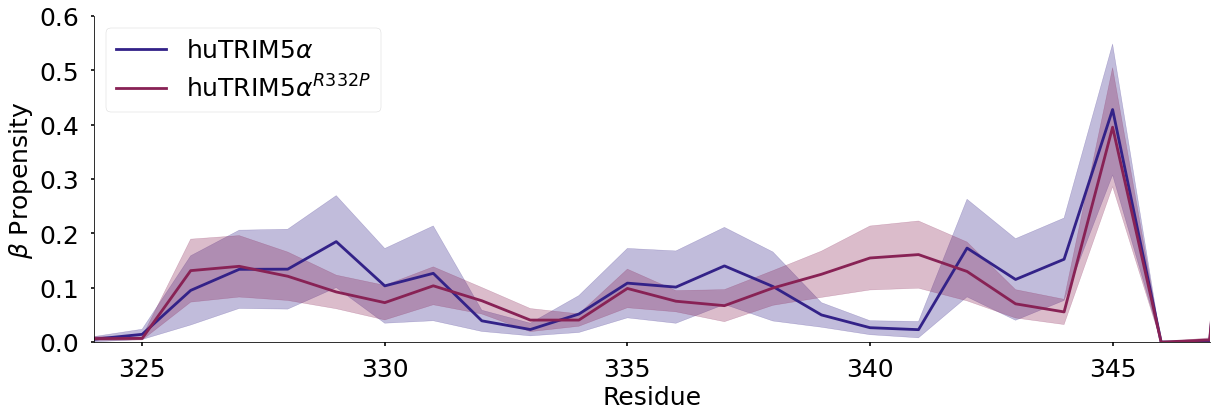

In [20]:
helicity=[]
betacity=[]
coilcity=[]
for i in range(len(system_names)):
    helicity.append(load(system_names[i]+"helicities.npy"))
    betacity.append(load(system_names[i]+"betacities.npy"))
    coilcity.append(load(system_names[i]+"coilcities.npy"))
    
avghelicities = []
avgbetacities = []
avgcoilcities = []
semhelicities = []
sembetacities = []
semcoilcities = []
for i in range(len(helicity)):
    avghelicities.append(mean(helicity[i],axis = 0))
    avgbetacities.append(mean(betacity[i],axis = 0))
    avgcoilcities.append(mean(coilcity[i],axis = 0))
    semhelicities.append(scipy.stats.sem(helicity[i],axis = 0))
    sembetacities.append(scipy.stats.sem(betacity[i],axis = 0))
    semcoilcities.append(scipy.stats.sem(coilcity[i],axis = 0))
    

    
#Let's insert nans into the human versions so that everything stays aligned

def insertMyNans(huArray,indices):
    huList = list(huArray)
    # Note, index list should be in descending order, otherwise there will be problems 
    # (since the index of later indexes will increase every time you make an insertion)
    for i in range(len(indices)):
        huList.insert(indices[i],nan)
    return array(huList)



mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

figure(figsize = (20,6))
for i in range(1,3):#len(avghelicities)):
    
    plot(huresids,avgbetacities[i],color = colourScheme[i],label = system_labels[i])
    fill_between(huresids, avgbetacities[i] - sembetacities[i],avgbetacities[i] + sembetacities[i],color = colourScheme[i],alpha = 0.3)

    
    
xlabel("Residue",fontsize = 25)
ylabel(r"$\beta$ Propensity",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25,loc = "upper left")

#xlim(405,430)
ylim(0,0.6)
#axvline(342)
xlim(324,347)

(0.0, 0.6)

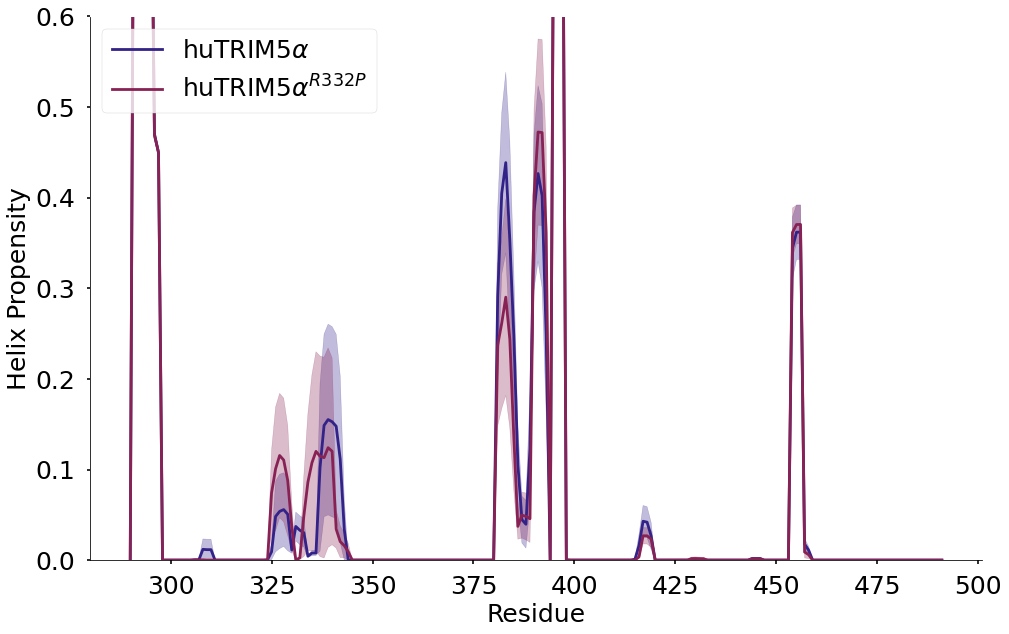

In [7]:
helicity=[]
betacity=[]
coilcity=[]
for i in range(len(system_names)):
    helicity.append(load(system_names[i]+"helicities.npy"))
    betacity.append(load(system_names[i]+"betacities.npy"))
    coilcity.append(load(system_names[i]+"coilcities.npy"))
    
avghelicities = []
avgbetacities = []
avgcoilcities = []
semhelicities = []
sembetacities = []
semcoilcities = []
for i in range(len(helicity)):
    avghelicities.append(mean(helicity[i],axis = 0))
    avgbetacities.append(mean(betacity[i],axis = 0))
    avgcoilcities.append(mean(coilcity[i],axis = 0))
    semhelicities.append(scipy.stats.sem(helicity[i],axis = 0))
    sembetacities.append(scipy.stats.sem(betacity[i],axis = 0))
    semcoilcities.append(scipy.stats.sem(coilcity[i],axis = 0))
    

    
#Let's insert nans into the human versions so that everything stays aligned

def insertMyNans(huArray,indices):
    huList = list(huArray)
    # Note, index list should be in descending order, otherwise there will be problems 
    # (since the index of later indexes will increase every time you make an insertion)
    for i in range(len(indices)):
        huList.insert(indices[i],nan)
    return array(huList)



mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

figure(figsize = (16,10))
for i in range(1,3):#len(avghelicities)):
    
    plot(huresids,avghelicities[i],color = colourScheme[i],label = system_labels[i])
    fill_between(huresids, avghelicities[i] - semhelicities[i],avghelicities[i] + semhelicities[i],color = colourScheme[i],alpha = 0.3)

    
    
xlabel("Residue",fontsize = 25)
ylabel(r"Helix Propensity",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25,loc = "upper left")

#xlim(405,430)
ylim(0,0.6)
#axvline(342)
#xlim(324,347)

In [8]:
avghelicities[2].shape

(202,)

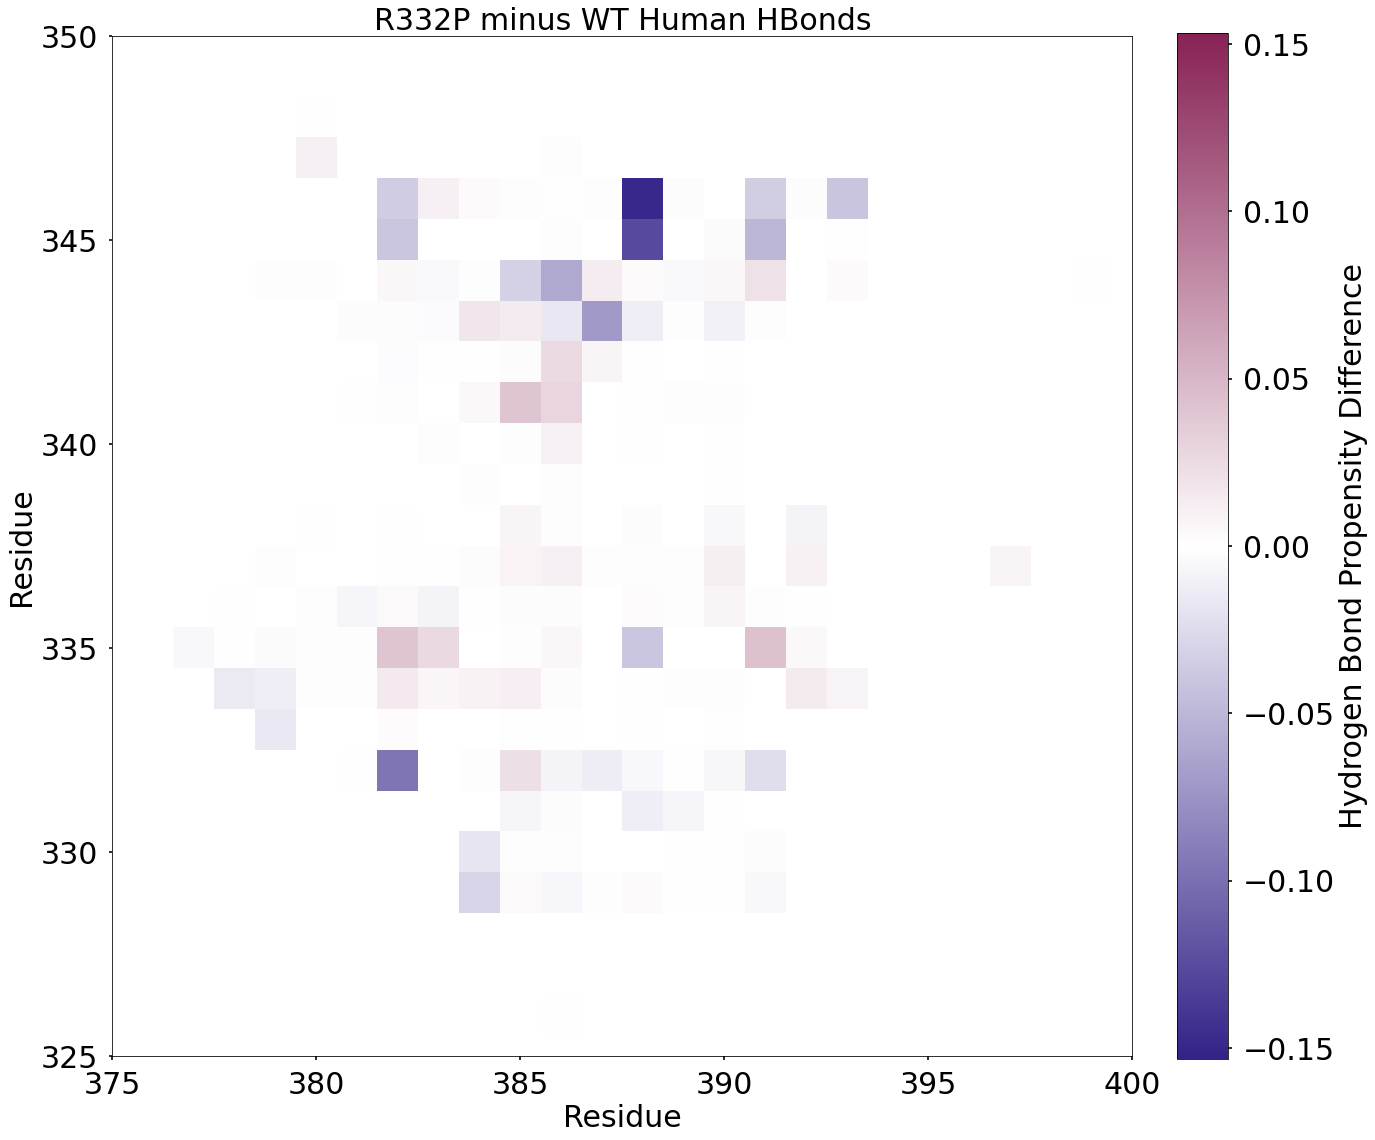

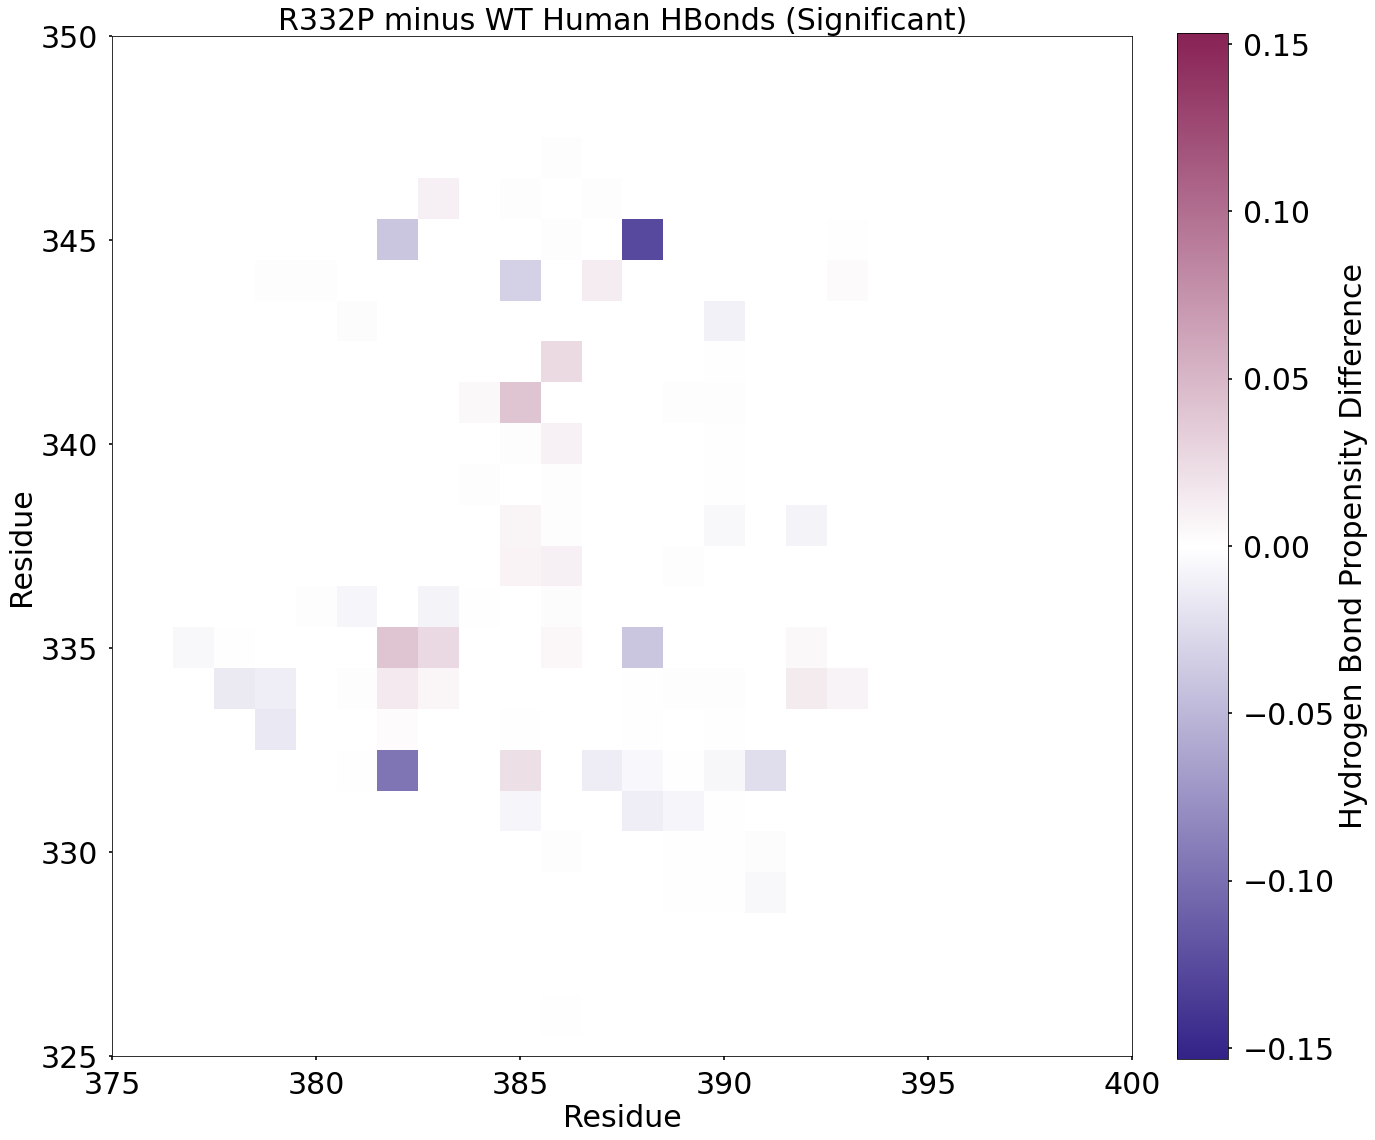

(35.0, 60.0)

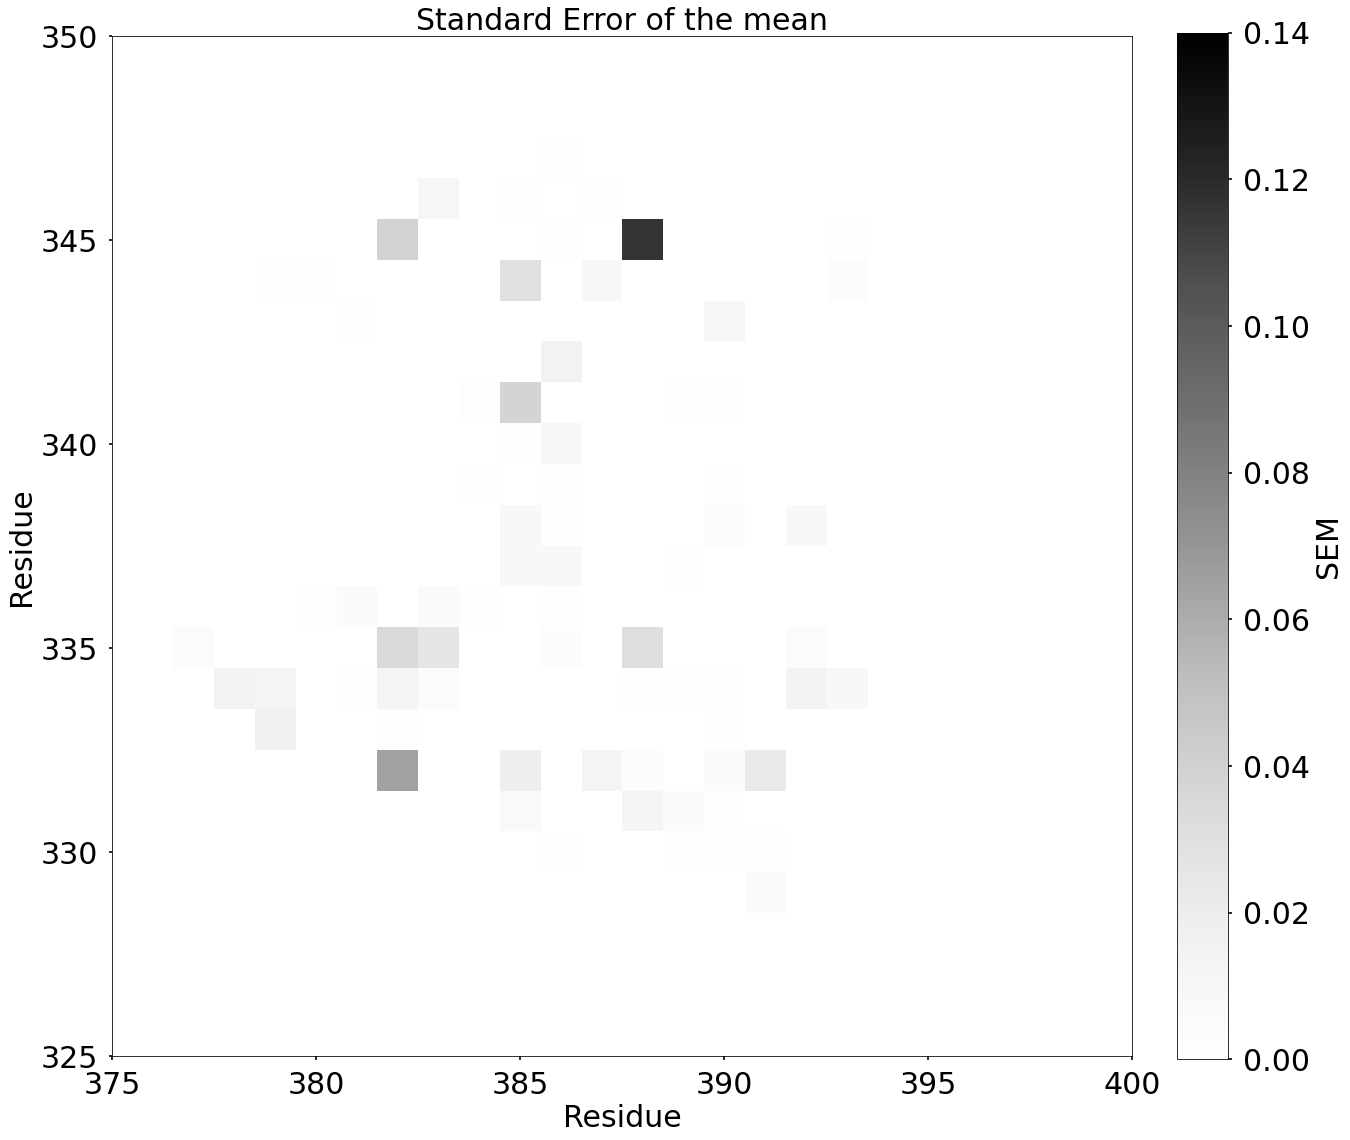

In [9]:


mpl.rcParams['axes.spines.right'] = True
mpl.rcParams['axes.spines.top'] = True

all_important_2d_hb_propensities_symmetric=[]

all_important_2d_hb_propensities_symmetric.append(load("all_2d_hb_propensities_symmetric_"+system_names[0]+".npy"))
all_important_2d_hb_propensities_symmetric.append(load("all_2d_hb_propensities_symmetric_"+system_names[1]+".npy"))

# take averages
system_avg_important_2d_hb_propensities=[]
system_sem_important_2d_hb_propensities=[]
for i in range(len(all_important_2d_hb_propensities_symmetric)):
    system_avg_important_2d_hb_propensities.append(mean(all_important_2d_hb_propensities_symmetric[i],axis = 0))
    system_sem_important_2d_hb_propensities.append(scipy.stats.sem(all_important_2d_hb_propensities_symmetric[i],axis =0))

    
diffmap = system_avg_important_2d_hb_propensities[1]-system_avg_important_2d_hb_propensities[0]
diffsem = sqrt(system_sem_important_2d_hb_propensities[1]**2 + system_sem_important_2d_hb_propensities[0]**2)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 1000)
newcolors = viridis(np.linspace(0, 1, 1000))
#This is what you pick
rs = concatenate([linspace(51,256,500),linspace(256,136,500)])/256
gs = concatenate([linspace(34,256,500),linspace(256,34,500)])/256
bs = concatenate([linspace(136,256,500),linspace(256,85,500)])/256
newColours = []
for i in range(len(rs)):
    newColours.append([rs[i],gs[i],bs[i],1])
newcolors = newColours
newcmp = ListedColormap(newcolors)
# K the peg colour we are usingn is: #882255   -   rgb(136, 34, 85)
#andthe nopegcolour we ar eusing is: #332288   -   rgb(51, 34, 136)


dr = max(abs(diffmap.flatten()))


figure(figsize = (20,20))
imshow(diffmap.T,origin = "lower",cmap = newcmp,vmax = dr,vmin = -dr)
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Hydrogen Bond Propensity Difference",fontsize = 30)
title("R332P minus WT Human HBonds",fontsize = 30)

xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
_=xticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)
_=yticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)



xlim(375-290,400-290)
ylim(325-290,350-290)


show()

significant_diffbars=copy(diffmap)
for i in range(len(diffmap)):
    for j in range(len(diffmap[i])):

        
        if abs(diffsem[i][j]) > abs(diffmap[i][j]):
            significant_diffbars[i][j] = 0
dr = max(abs(diffmap.flatten()))


figure(figsize = (20,20))
imshow(significant_diffbars.T,origin = "lower",cmap = newcmp,vmax = dr,vmin = -dr)
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Hydrogen Bond Propensity Difference",fontsize = 30)
title("R332P minus WT Human HBonds (Significant)",fontsize = 30)

xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
_=xticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)
_=yticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)



xlim(375-290,400-290)
ylim(325-290,350-290)
show()


significant_sembars=copy(diffsem)
for i in range(len(diffsem)):
    for j in range(len(diffsem[i])):

        
        if abs(diffsem[i][j]) > abs(diffmap[i][j]):
            significant_sembars[i][j] = 0
            
dr = max(abs(significant_sembars.flatten()))
figure(figsize = (20,20))
imshow(significant_sembars.T,origin = "lower",cmap = "Greys",vmax = .14,vmin = 0)
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("SEM",fontsize = 30)
title("Standard Error of the mean",fontsize = 30)

xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
_=xticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)
_=yticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)



xlim(375-290,400-290)
ylim(325-290,350-290)

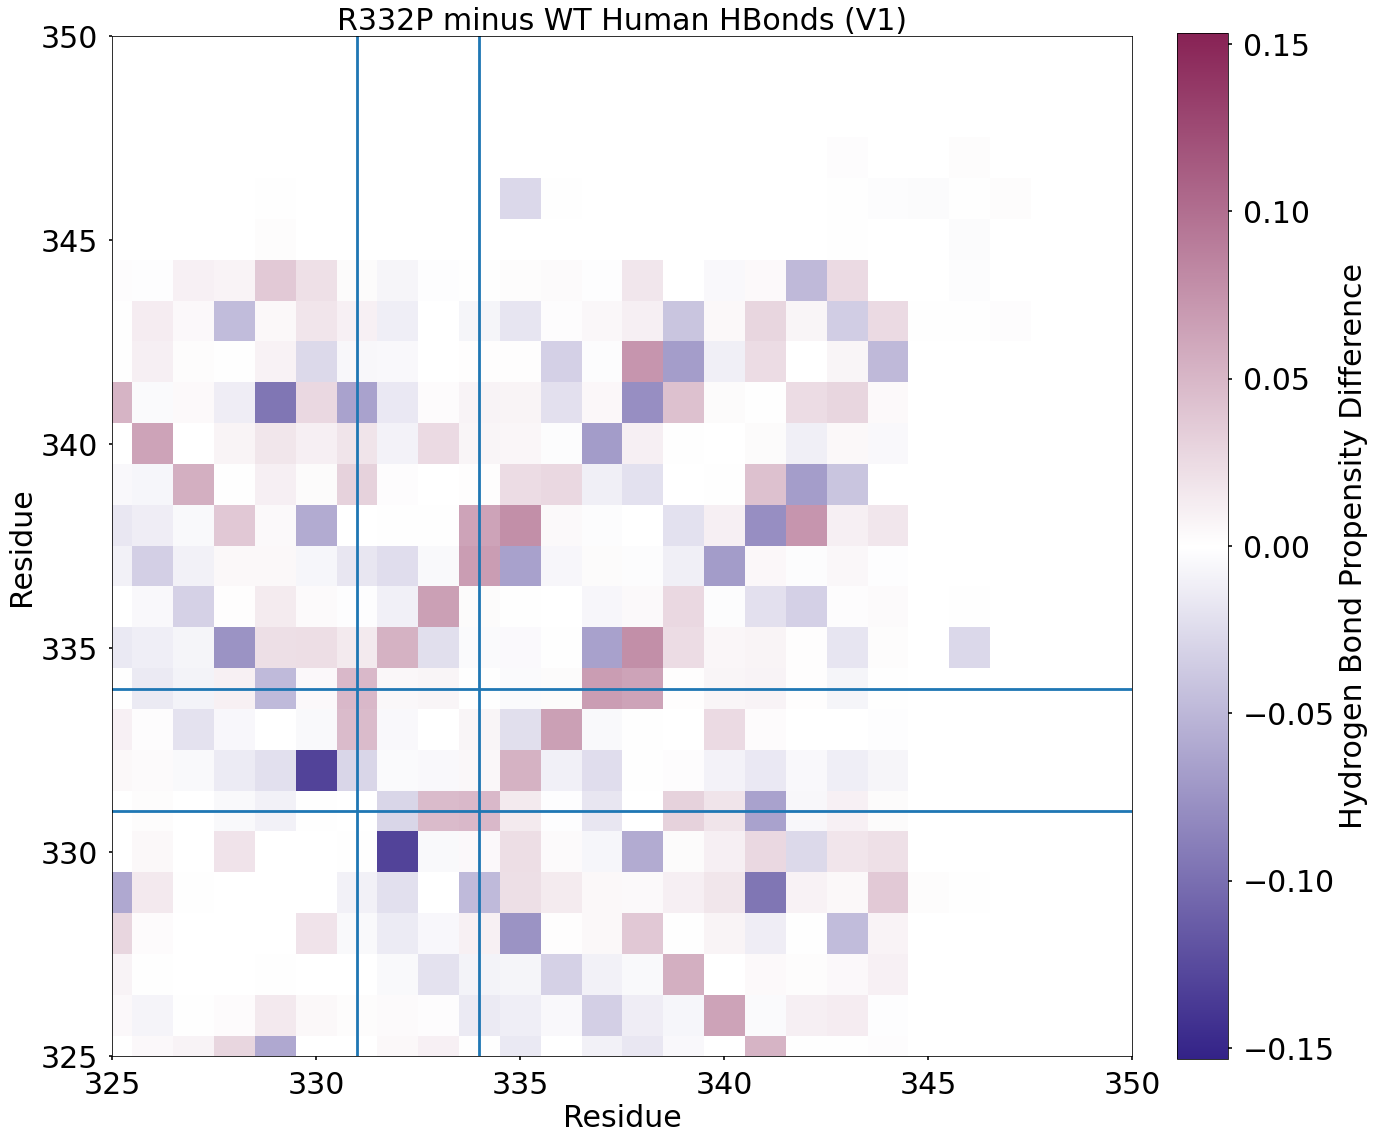

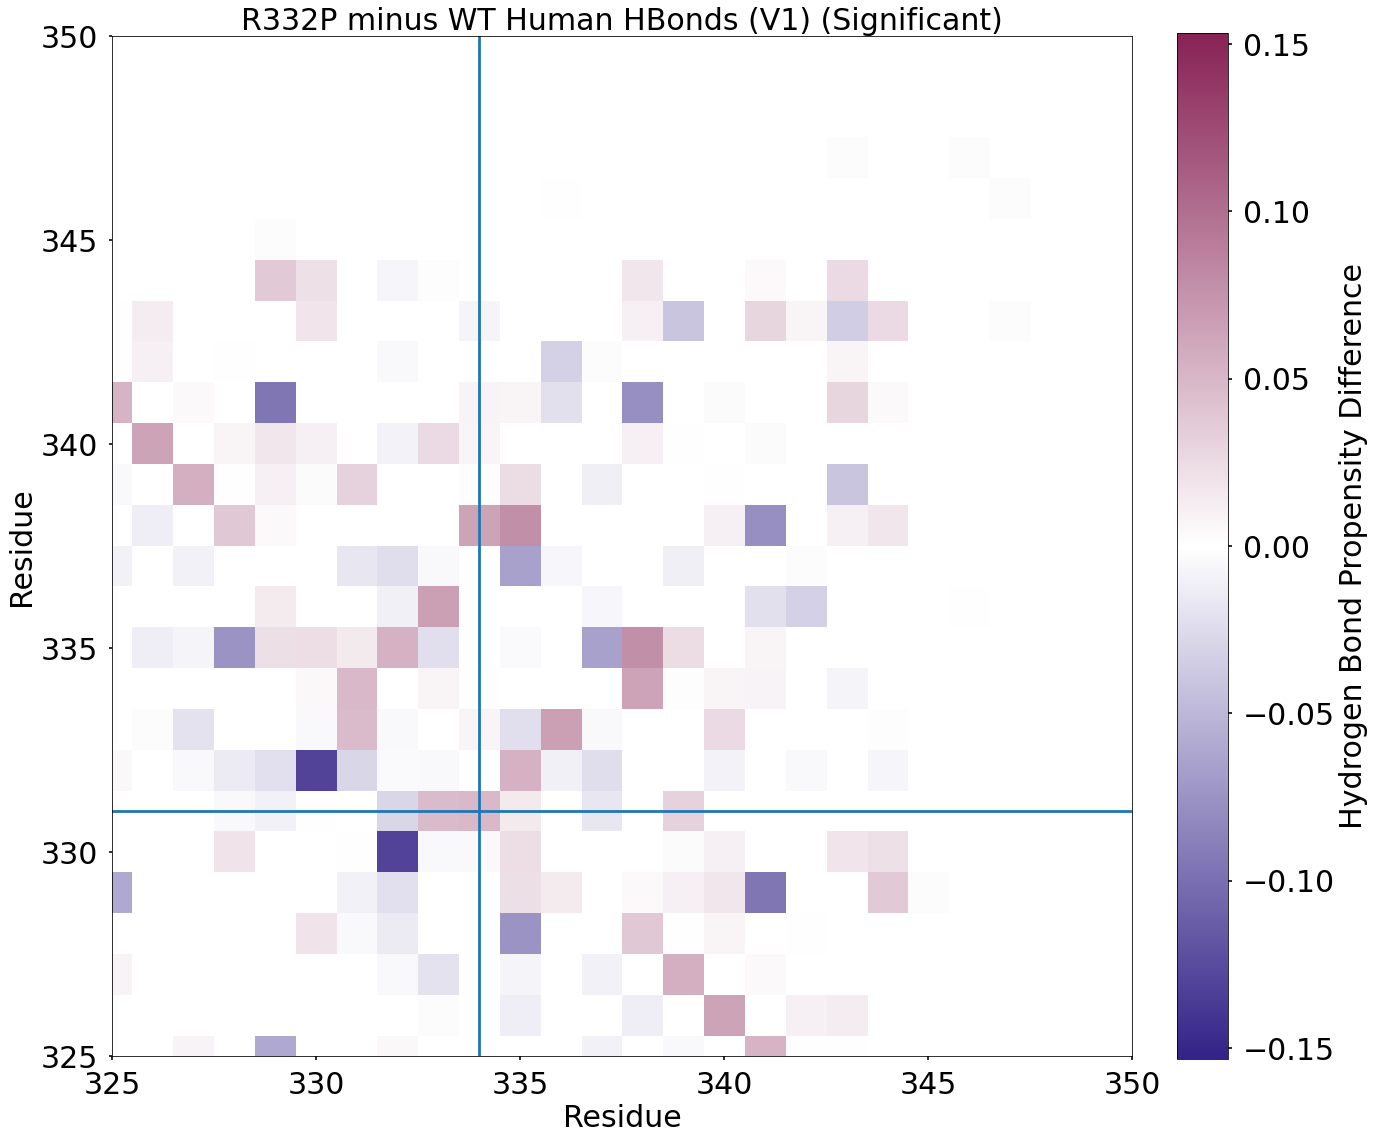

(35.0, 60.0)

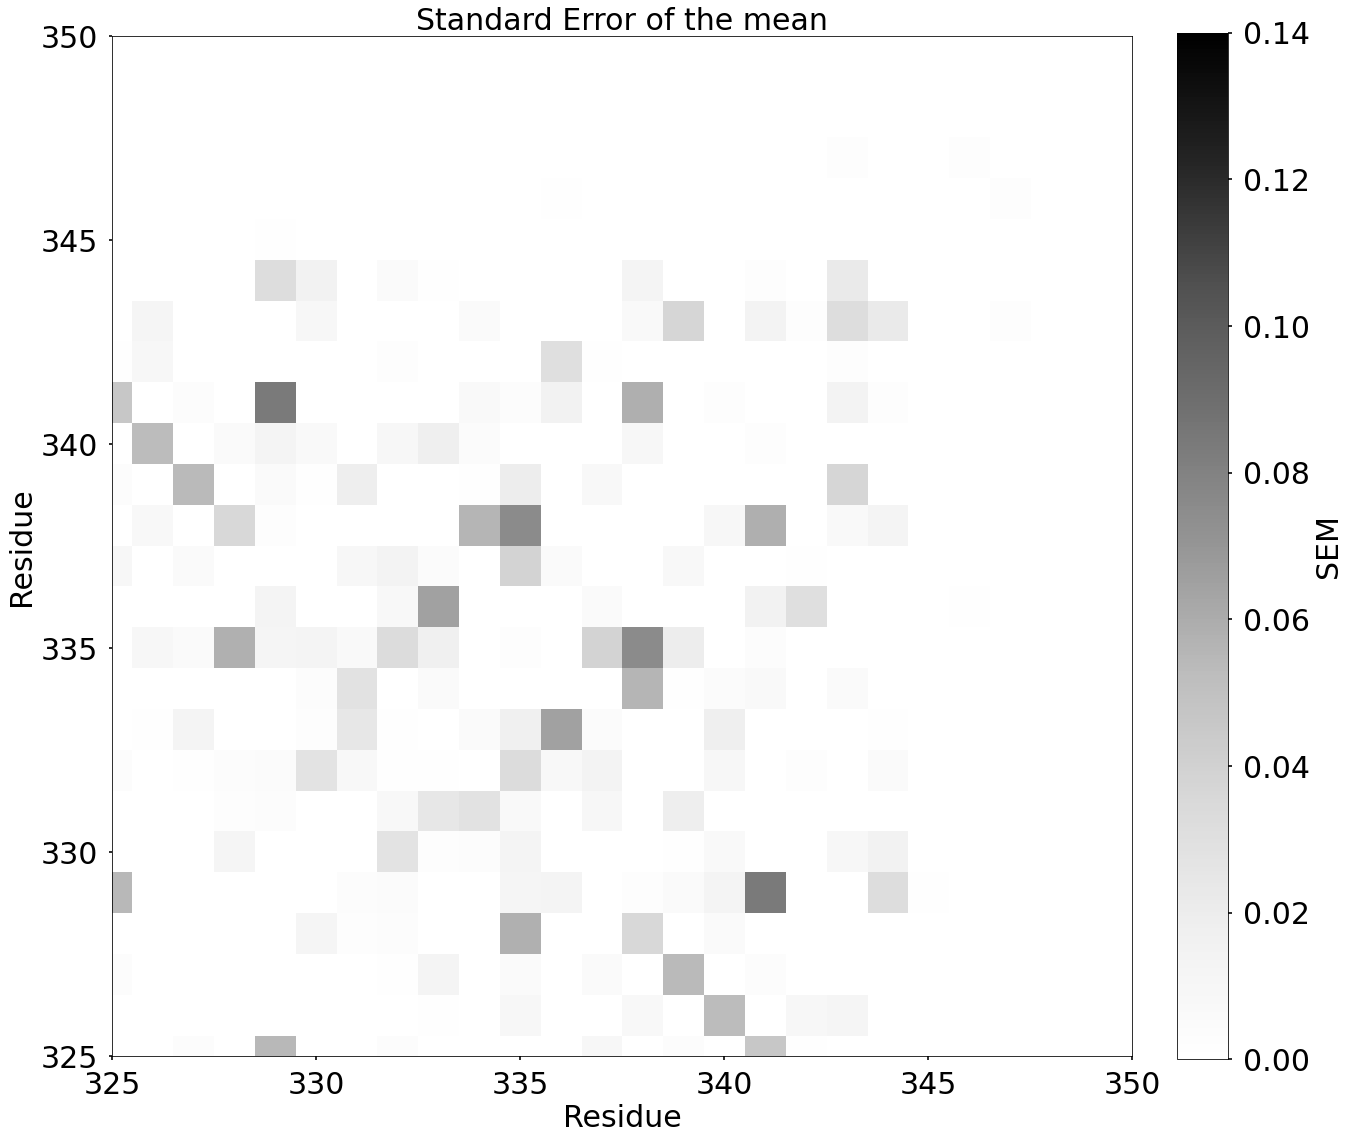

In [10]:


mpl.rcParams['axes.spines.right'] = True
mpl.rcParams['axes.spines.top'] = True

all_important_2d_hb_propensities_symmetric=[]

all_important_2d_hb_propensities_symmetric.append(load("all_2d_hb_propensities_symmetric_"+system_names[0]+".npy"))
all_important_2d_hb_propensities_symmetric.append(load("all_2d_hb_propensities_symmetric_"+system_names[1]+".npy"))

# take averages
system_avg_important_2d_hb_propensities=[]
system_sem_important_2d_hb_propensities=[]
for i in range(len(all_important_2d_hb_propensities_symmetric)):
    system_avg_important_2d_hb_propensities.append(mean(all_important_2d_hb_propensities_symmetric[i],axis = 0))
    system_sem_important_2d_hb_propensities.append(scipy.stats.sem(all_important_2d_hb_propensities_symmetric[i],axis =0))

    
diffmap = system_avg_important_2d_hb_propensities[1]-system_avg_important_2d_hb_propensities[0]
diffsem = sqrt(system_sem_important_2d_hb_propensities[1]**2 + system_sem_important_2d_hb_propensities[0]**2)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 1000)
newcolors = viridis(np.linspace(0, 1, 1000))
#This is what you pick
rs = concatenate([linspace(51,256,500),linspace(256,136,500)])/256
gs = concatenate([linspace(34,256,500),linspace(256,34,500)])/256
bs = concatenate([linspace(136,256,500),linspace(256,85,500)])/256
newColours = []
for i in range(len(rs)):
    newColours.append([rs[i],gs[i],bs[i],1])
newcolors = newColours
newcmp = ListedColormap(newcolors)
# K the peg colour we are usingn is: #882255   -   rgb(136, 34, 85)
#andthe nopegcolour we ar eusing is: #332288   -   rgb(51, 34, 136)


dr = max(abs(diffmap.flatten()))


figure(figsize = (20,20))
imshow(diffmap.T,origin = "lower",cmap = newcmp,vmax = dr,vmin = -dr)
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Hydrogen Bond Propensity Difference",fontsize = 30)
title("R332P minus WT Human HBonds (V1)",fontsize = 30)

xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
_=xticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)
_=yticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)

axhline(331-290)
axvline(334-290)
axvline(331-290)
axhline(334-290)


xlim(325-290,350-290)
ylim(325-290,350-290)


show()

significant_diffbars=copy(diffmap)
for i in range(len(diffmap)):
    for j in range(len(diffmap[i])):

        
        if abs(diffsem[i][j]) > abs(diffmap[i][j]):
            significant_diffbars[i][j] = 0
dr = max(abs(diffmap.flatten()))


figure(figsize = (20,20))
imshow(significant_diffbars.T,origin = "lower",cmap = newcmp,vmax = dr,vmin = -dr)
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Hydrogen Bond Propensity Difference",fontsize = 30)
title("R332P minus WT Human HBonds (V1) (Significant)",fontsize = 30)

xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
_=xticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)
_=yticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)



axhline(331-290)
axvline(334-290)

xlim(325-290,350-290)
ylim(325-290,350-290)
show()


significant_sembars=copy(diffsem)
for i in range(len(diffsem)):
    for j in range(len(diffsem[i])):

        
        if abs(diffsem[i][j]) > abs(diffmap[i][j]):
            significant_sembars[i][j] = 0
            
dr = max(abs(significant_sembars.flatten()))
figure(figsize = (20,20))
imshow(significant_sembars.T,origin = "lower",cmap = "Greys",vmax = .14,vmin = 0)
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("SEM",fontsize = 30)
title("Standard Error of the mean",fontsize = 30)

xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
_=xticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)
_=yticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)



xlim(325-290,350-290)
ylim(325-290,350-290)

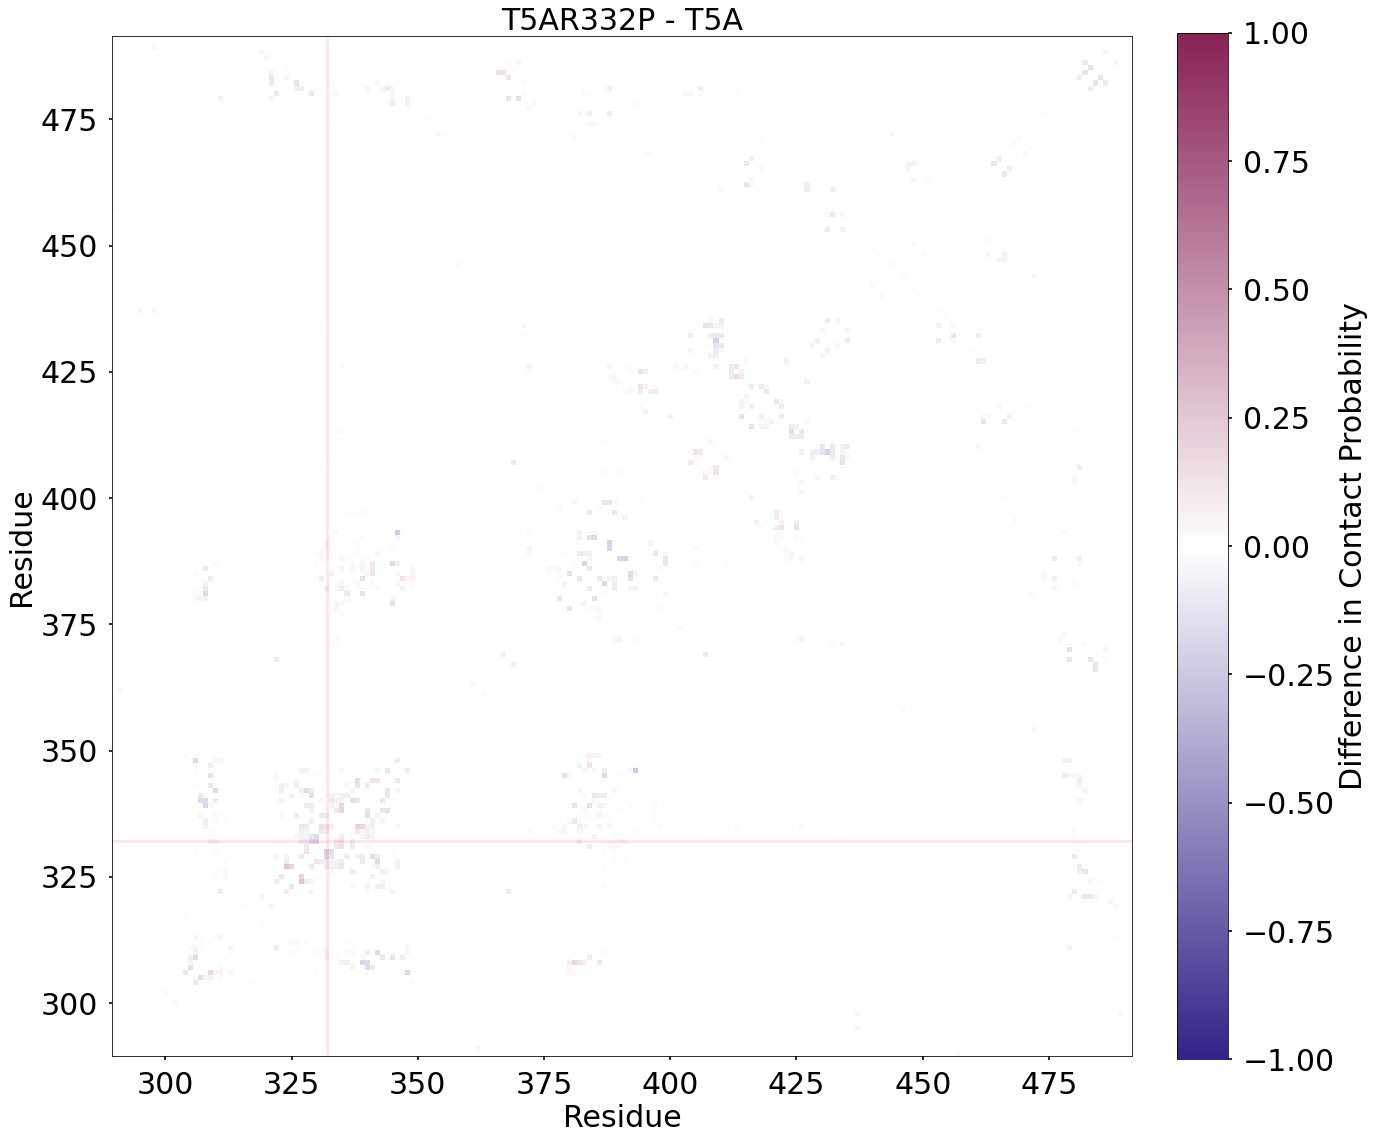

In [11]:
allcontacts=load("allcontacts_mean.npy",allow_pickle = True)

avg_contacts=[]
sem_contacts=[]
for i in range(len(allcontacts)):
    avg_contacts.append(mean(allcontacts[i],axis = 0))
    sem_contacts.append(scipy.stats.sem(list(allcontacts[i]),axis = 0))
    
def BestTwoD(array1d):
    #The number of dimensions (excluding nearest neighbours and self)
    N = int(1.5 + .5*np.sqrt(1+(8*len(array1d))))

    #Construct a 2D version of the contact map (it excludes nearesty neighbours and self, but there are still NxN slots)
    twoD=zeros((N,N))            
    j=2
    k=0
    for i in range(len(array1d)):
        if abs(j-k)>1:
            twoD[j][k] = array1d[i]
            twoD[k][j] = array1d[i]
        j+=1
        if j == len(twoD):
            k+=1
            j = k+2
            if k==len(twoD)-2 and j >len(twoD)-2 :
                break
    return twoD

avg_contacts_2d =[]
sem_contacts_2d =[]
for i in range(len(avg_contacts)):
    avg_contacts_2d.append(BestTwoD(avg_contacts[i]))
    sem_contacts_2d.append(BestTwoD(sem_contacts[i]))
    
diffmap = avg_contacts_2d[2] - avg_contacts_2d[1]
semDiffBars = sqrt(sem_contacts_2d[2]**2 + sem_contacts_2d[1]**2)

significant_diffbars=copy(diffmap)
for i in range(len(diffmap)):
    for j in range(len(diffmap[i])):
        if abs(semDiffBars[i][j]) > abs(diffmap[i][j]):
            significant_diffbars[i][j] = 0

            
viridis = cm.get_cmap('viridis', 1000)
newcolors = viridis(np.linspace(0, 1, 1000))
#This is what you pick
rs = concatenate([linspace(51,256,500),linspace(256,136,500)])/256
gs = concatenate([linspace(34,256,500),linspace(256,34,500)])/256
bs = concatenate([linspace(136,256,500),linspace(256,85,500)])/256
newColours = []
for i in range(len(rs)):
    newColours.append([rs[i],gs[i],bs[i],1])
newcolors = newColours
newcmp = ListedColormap(newcolors)


figure(figsize = (20,20))
imshow(significant_diffbars,origin = "lower",cmap=newcmp,vmin=-1,vmax=1,extent = (huresids[0]-0.5,huresids[-1]+0.5,huresids[0]-0.5,huresids[-1]+0.5))

#5.55.55.5
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Difference in Contact Probability",fontsize = 30)
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
title(system_names[2] + " - " + system_names[1],fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)
axvline(332,alpha = 0.1, color = 'red')
axhline(332,alpha = 0.1, color = 'red')
            

#axvspan(324,345,color = "purple", alpha = 0.1)
#axvspan(376,396,color = "violet", alpha = 0.1)
#axvspan(414,425,color = "pink", alpha = 0.1)
##axvspan(483,489,color = "red", alpha = 0.1)

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

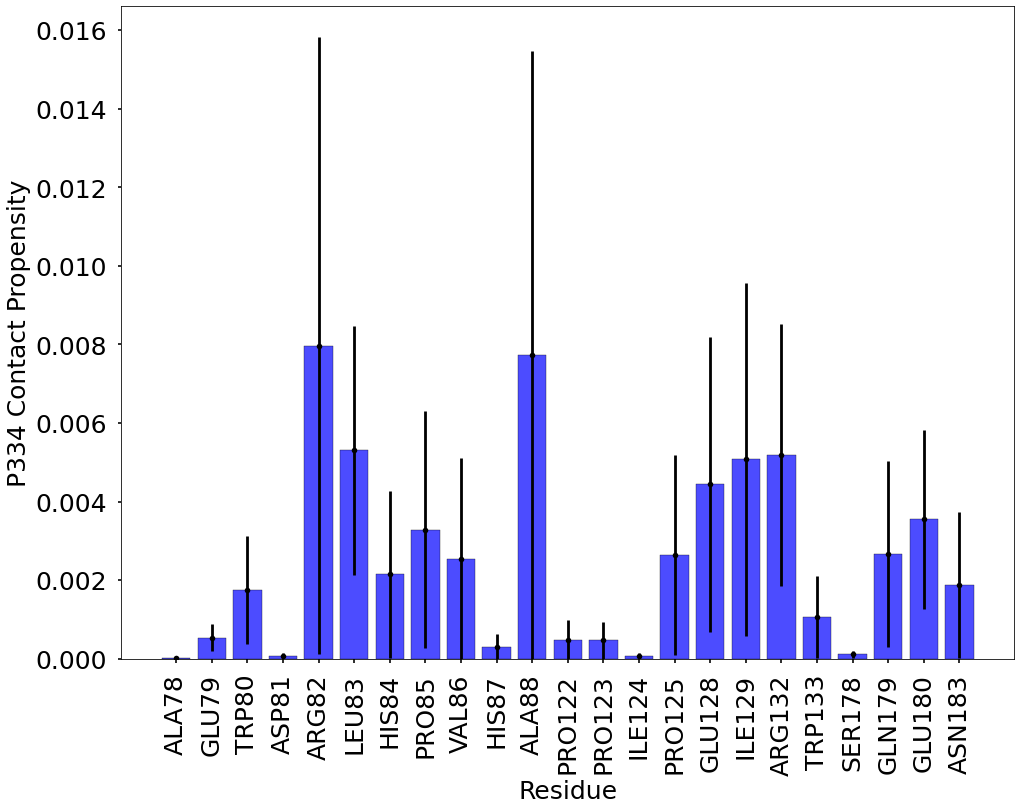

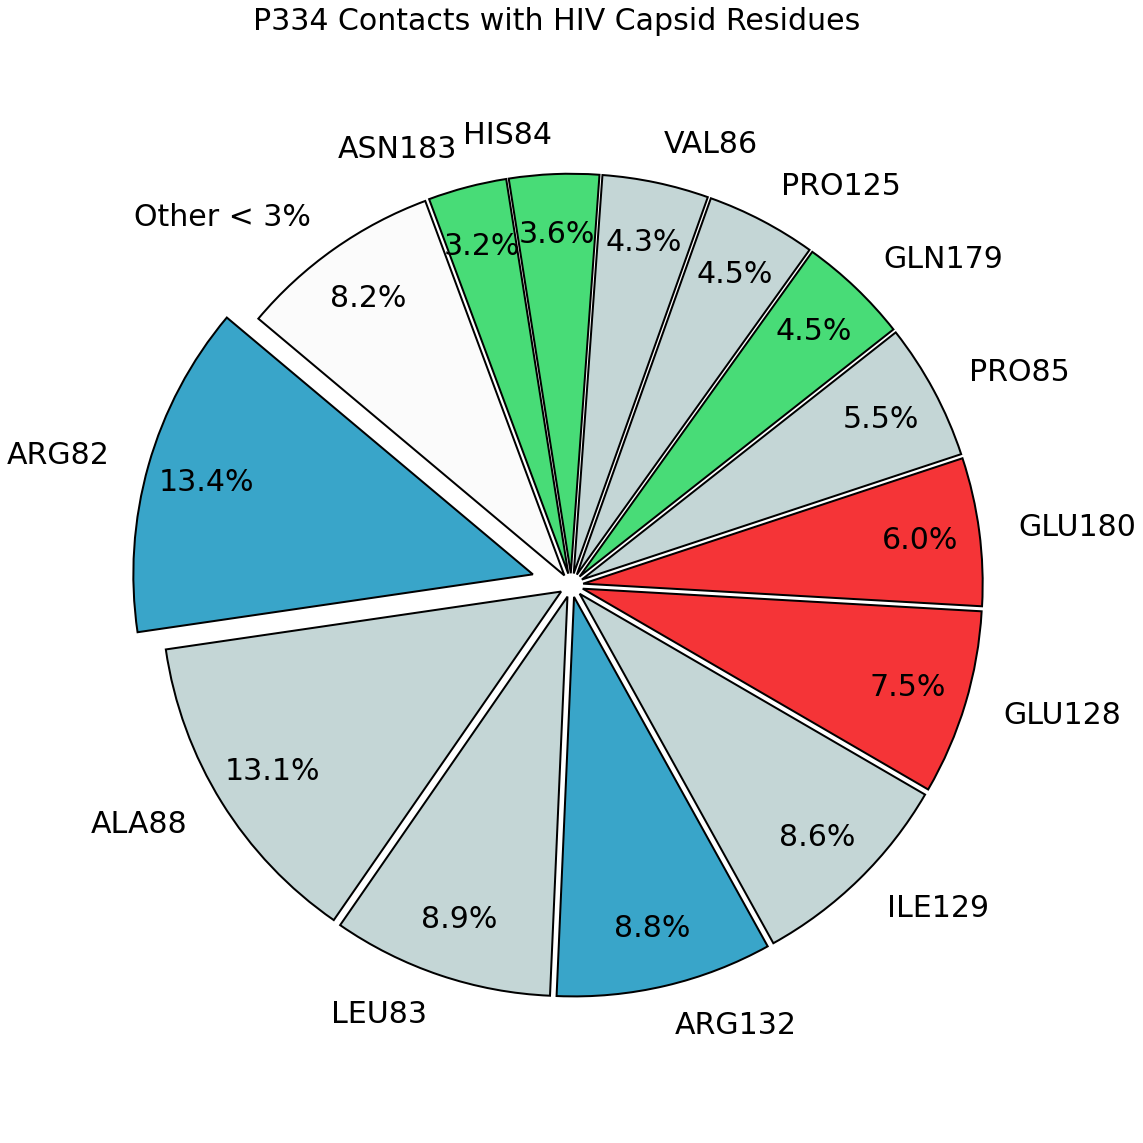

In [12]:
complexRef = mda.Universe("../complex/1/3_npt/protein_cluster_center_ff.gro")
hivseq = complexRef.select_atoms("resid 1:231").residues.resnames[:231]

all_contacts_2d = []
for i in range(5):
    all_contacts_2d.append(load("../complex/complexContacts_2d_trajectory"+str(i+1)+".npy"))
    
contacts_2d = mean(all_contacts_2d,axis = 0)
contacts_2d_sem = scipy.stats.sem(all_contacts_2d,axis = 0)
nspry = 493-290 

contacts_by_CA=[]
contacts_by_CA_sem_sq=[]
for i in range(1,18+1):
    contacts_by_CA.append(contacts_2d[:nspry+1,1+nspry+(231*(i-1)):1+nspry+(231*(i))])
    contacts_by_CA_sem_sq.append(contacts_2d_sem[:nspry+1,1+nspry+(231*(i-1)):1+nspry+(231*(i))]**2)

    
mean_332_contacts = mean(contacts_by_CA,axis = 0)[332-290]
sem_332_contacts = sqrt(sum(contacts_by_CA_sem_sq,axis = 0))[332-290]/18
nonzero_indices=list(where(mean_332_contacts >0)[0])

all_nonzero_resids = []
all_nonzero_resids_ints=[]
all_nonzero_resids_andNames=[]
for i in range(len(nonzero_indices)):
    all_nonzero_resids.append(str(nonzero_indices[i]))
    all_nonzero_resids_andNames.append(hivseq[nonzero_indices[i]]+str(nonzero_indices[i]+1))
    
    all_nonzero_resids_ints.append((nonzero_indices[i]))


system_non_zero_propensities=mean_332_contacts[nonzero_indices]
#system_non_zero_sem=mean_332_contacts[all_nonzero_indices]
    
    
figure(figsize = (16,12))
bar(all_nonzero_resids_andNames,system_non_zero_propensities,alpha = .7,color = "blue",edgecolor = "black")
errorbar(all_nonzero_resids_andNames,system_non_zero_propensities,sem_332_contacts[nonzero_indices],fmt=".",color = "black")


#legend(fontsize = 25)
xlabel("Residue",fontsize = 25)
ylabel("P334 Contact Propensity",fontsize = 25)
sakdfjahsfk=xticks(fontsize = 25,rotation = 90)
akldsfhskfr=yticks(fontsize = 25)    

show()




# Assuming system_non_zero_propensities and all_nonzero_resids_andNames are defined
sizes = system_non_zero_propensities / sum(system_non_zero_propensities) * 100
labels = all_nonzero_resids_andNames

# Sort sizes and labels based on sizes in descending order
sorted_indices = np.argsort(sizes)[::-1]
sorted_sizes = sizes[sorted_indices]
sorted_labels = [labels[i] for i in sorted_indices]


# Extract residue codes from labels (assume residues are the first three letters of each label)
residue_codes = [label[:3] for label in sorted_labels]  # Extract three-letter residue code

# Map residues to colors
color_map = {
    'LYS': '#39a5c9', 'ARG': '#39a5c9',  # Positive residues
    'ASP': '#f53437', 'GLU': '#f53437',  # Negative residues
    'ALA': '#c4d6d6', 'VAL': '#c4d6d6', 'LEU': '#c4d6d6', 'ILE': '#c4d6d6', 'MET': '#c4d6d6', 'PHE': '#c4d6d6', 'TYR': '#c4d6d6', 'TRP': '#c4d6d6', 'PRO': '#c4d6d6',  # Nonpolar residues
    'HIS': '#48dc77', 'ASN': '#48dc77', 'GLN': '#48dc77', 'SER': '#48dc77', 'THR': '#48dc77', 'CYS': '#48dc77', 'GLY': '#48dc77'  # Polar residues
}

colors = [color_map.get(code) for code in residue_codes]



# Combine all slices < 3% into "Other < 3%"
threshold = 3  # Define the threshold percentage
other_size = sum([size for size in sorted_sizes if size < threshold])
filtered_sizes = [size for size in sorted_sizes if size >= threshold]
filtered_labels = [label for label, size in zip(sorted_labels, sorted_sizes) if size >= threshold]

# Add the "Other < 3%" category
if other_size > 0:
    filtered_sizes.append(other_size)
    filtered_labels.append("Other < 3%")

# Choose a color map, e.g., 'rainbow'
#colors = plt.cm.rainbow(np.linspace(0, 1, len(filtered_sizes)))
colors[len(filtered_labels)-1] = array([350,350,350,355])/355
# Define a function to scale explode values with better control
def controlled_explode(size, max_explode=0.1, min_explode=0):
    return max_explode * (1 - np.sqrt(size / 100)) + min_explode

# Apply the explode function to all remaining sizes
explode = [controlled_explode(size) for size in filtered_sizes]
explode = array(explode)*0+.03
explode[0] = .1
# Create the pie chart with enhancements
plt.figure(figsize=(16, 16))  # Increase the size of the figure
wedges, texts, autotexts = plt.pie(filtered_sizes, 
                                   labels=filtered_labels, 
                                   colors=colors, 
                                   autopct='%1.1f%%',  # Display percentages on the chart
                                   startangle=140,     # Start the chart at a different angle
                                   explode=explode,    # Explode based on controlled scaling
                                   wedgeprops={'edgecolor': 'black', 'linewidth': 2},  # Add borders to slices
                                   textprops={'fontsize': 30},  # Adjust label font size
                                   pctdistance=0.85)   # Position percentage text_variable slightly outside

# Adjust label position
for text_variable in texts:
    text_variable.set_fontsize(30)
    #text_variable.set_horizontalalignment('center')

# Adjust the percentage text_variable position and styling
for autotext_variable in autotexts:
    autotext_variable.set_color('black')
    autotext_variable.set_fontsize(30)

# Draw lines from labels to their corresponding slices
#plt.legend(wedges, filtered_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=25)

# Equal aspect ratio ensures the pie chart is circular
plt.axis('equal')  
plt.title('P334 Contacts with HIV Capsid Residues',fontsize = 30)
plt.tight_layout()
plt.show()

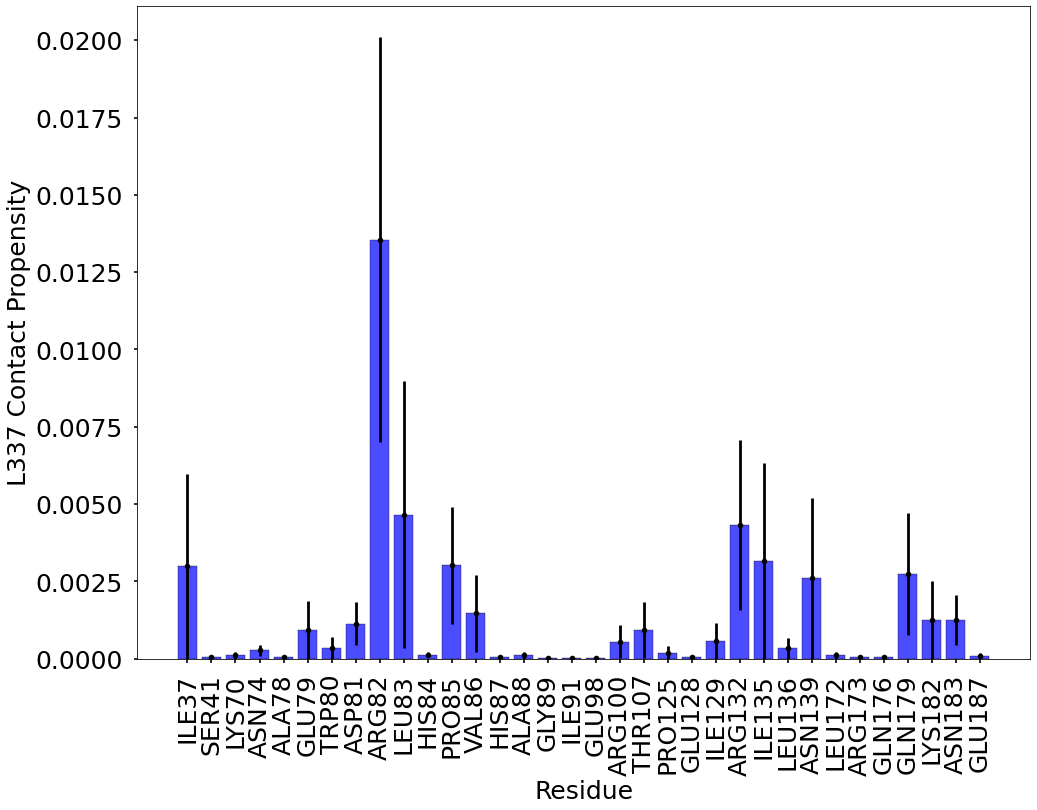

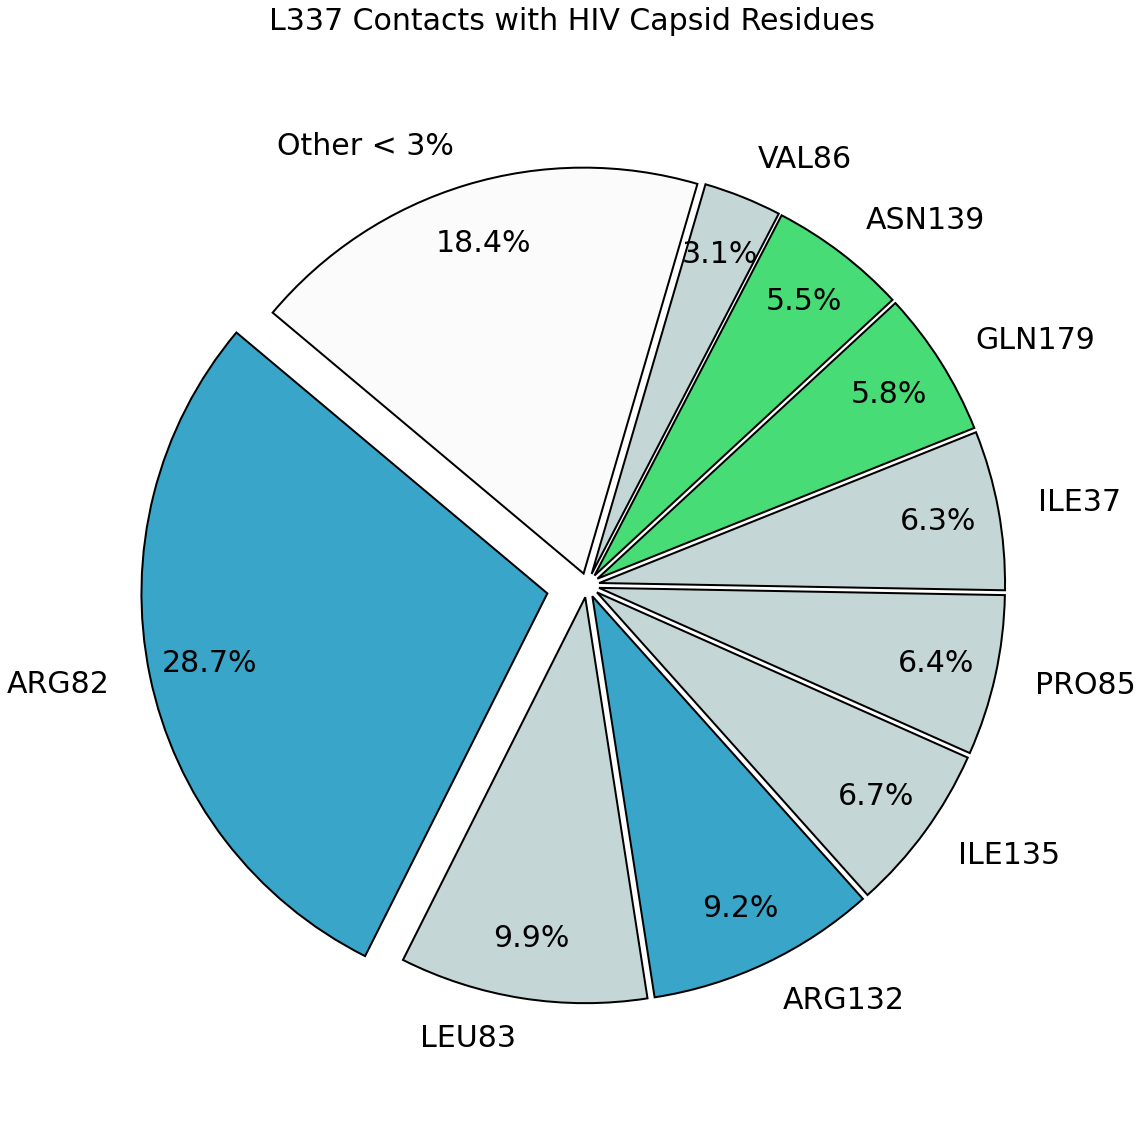

In [13]:
complexRef = mda.Universe("../complex/1/3_npt/protein_cluster_center_ff.gro")
hivseq = complexRef.select_atoms("resid 1:231").residues.resnames[:231]

all_contacts_2d = []
for i in range(5):
    all_contacts_2d.append(load("../complex/complexContacts_2d_trajectory"+str(i+1)+".npy"))
    
contacts_2d = mean(all_contacts_2d,axis = 0)
contacts_2d_sem = scipy.stats.sem(all_contacts_2d,axis = 0)
nspry = 493-290 

contacts_by_CA=[]
contacts_by_CA_sem_sq=[]
for i in range(1,18+1):
    contacts_by_CA.append(contacts_2d[:nspry+1,1+nspry+(231*(i-1)):1+nspry+(231*(i))])
    contacts_by_CA_sem_sq.append(contacts_2d_sem[:nspry+1,1+nspry+(231*(i-1)):1+nspry+(231*(i))]**2)

    
mean_335_contacts = mean(contacts_by_CA,axis = 0)[335-290]
sem_335_contacts = sqrt(sum(contacts_by_CA_sem_sq,axis = 0))[335-290]/18
nonzero_indices=list(where(mean_335_contacts >0)[0])

all_nonzero_resids = []
all_nonzero_resids_ints=[]
all_nonzero_resids_andNames=[]
for i in range(len(nonzero_indices)):
    all_nonzero_resids.append(str(nonzero_indices[i]))
    all_nonzero_resids_andNames.append(hivseq[nonzero_indices[i]]+str(nonzero_indices[i]+1))
    
    all_nonzero_resids_ints.append((nonzero_indices[i]))


system_non_zero_propensities=mean_335_contacts[nonzero_indices]
#system_non_zero_sem=mean_335_contacts[all_nonzero_indices]
    
    
figure(figsize = (16,12))
bar(all_nonzero_resids_andNames,system_non_zero_propensities,alpha = .7,color = "blue",edgecolor = "black")
errorbar(all_nonzero_resids_andNames,system_non_zero_propensities,sem_335_contacts[nonzero_indices],fmt=".",color = "black")


#legend(fontsize = 25)
xlabel("Residue",fontsize = 25)
ylabel("L337 Contact Propensity",fontsize = 25)
sakdfjahsfk=xticks(fontsize = 25,rotation = 90)
akldsfhskfr=yticks(fontsize = 25)    


show()






# Assuming system_non_zero_propensities and all_nonzero_resids_andNames are defined
sizes = system_non_zero_propensities / sum(system_non_zero_propensities) * 100
labels = all_nonzero_resids_andNames

# Sort sizes and labels based on sizes in descending order
sorted_indices = np.argsort(sizes)[::-1]
sorted_sizes = sizes[sorted_indices]
sorted_labels = [labels[i] for i in sorted_indices]

# Extract residue codes from labels (assume residues are the first three letters of each label)
residue_codes = [label[:3] for label in sorted_labels]  # Extract three-letter residue code

# Map residues to colors
color_map = {
    'LYS': '#39a5c9', 'ARG': '#39a5c9',  # Positive residues
    'ASP': '#f53437', 'GLU': '#f53437',  # Negative residues
    'ALA': '#c4d6d6', 'VAL': '#c4d6d6', 'LEU': '#c4d6d6', 'ILE': '#c4d6d6', 'MET': '#c4d6d6', 'PHE': '#c4d6d6', 'TYR': '#c4d6d6', 'TRP': '#c4d6d6', 'PRO': '#c4d6d6',  # Nonpolar residues
    'HIS': '#48dc77', 'ASN': '#48dc77', 'GLN': '#48dc77', 'SER': '#48dc77', 'THR': '#48dc77', 'CYS': '#48dc77', 'GLY': '#48dc77'  # Polar residues
}

colors = [color_map.get(code) for code in residue_codes]





# Combine all slices < 3% into "Other < 3%"
threshold = 3  # Define the threshold percentage
other_size = sum([size for size in sorted_sizes if size < threshold])
filtered_sizes = [size for size in sorted_sizes if size >= threshold]
filtered_labels = [label for label, size in zip(sorted_labels, sorted_sizes) if size >= threshold]

# Add the "Other < 3%" category
if other_size > 0:
    filtered_sizes.append(other_size)
    filtered_labels.append("Other < 3%")

# Choose a color map, e.g., 'rainbow'
#colors = plt.cm.rainbow(np.linspace(0, 1, len(filtered_sizes)))
colors[len(filtered_labels)-1] = array([350,350,350,355])/355
# Define a function to scale explode values with better control
def controlled_explode(size, max_explode=0.1, min_explode=0):
    return max_explode * (1 - np.sqrt(size / 100)) + min_explode

# Apply the explode function to all remaining sizes
explode = [controlled_explode(size) for size in filtered_sizes]
explode = array(explode)*0+.03
explode[0] = .1
# Create the pie chart with enhancements
plt.figure(figsize=(16, 16))  # Increase the size of the figure
wedges, texts, autotexts = plt.pie(filtered_sizes, 
                                   labels=filtered_labels, 
                                   colors=colors, 
                                   autopct='%1.1f%%',  # Display percentages on the chart
                                   startangle=140,     # Start the chart at a different angle
                                   explode=explode,    # Explode based on controlled scaling
                                   wedgeprops={'edgecolor': 'black', 'linewidth': 2},  # Add borders to slices
                                   textprops={'fontsize': 30},  # Adjust label font size
                                   pctdistance=0.85)   # Position percentage text_variable slightly outside

# Adjust label position
for text_variable in texts:
    text_variable.set_fontsize(30)
    #text_variable.set_horizontalalignment('center')

# Adjust the percentage text_variable position and styling
for autotext_variable in autotexts:
    autotext_variable.set_color('black')
    autotext_variable.set_fontsize(30)

# Draw lines from labels to their corresponding slices
#plt.legend(wedges, filtered_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=25)

# Equal aspect ratio ensures the pie chart is circular
plt.axis('equal')  
plt.title('L337 Contacts with HIV Capsid Residues',fontsize = 30)

plt.tight_layout()
plt.show()











Text(0.5, 0, 'Residue')

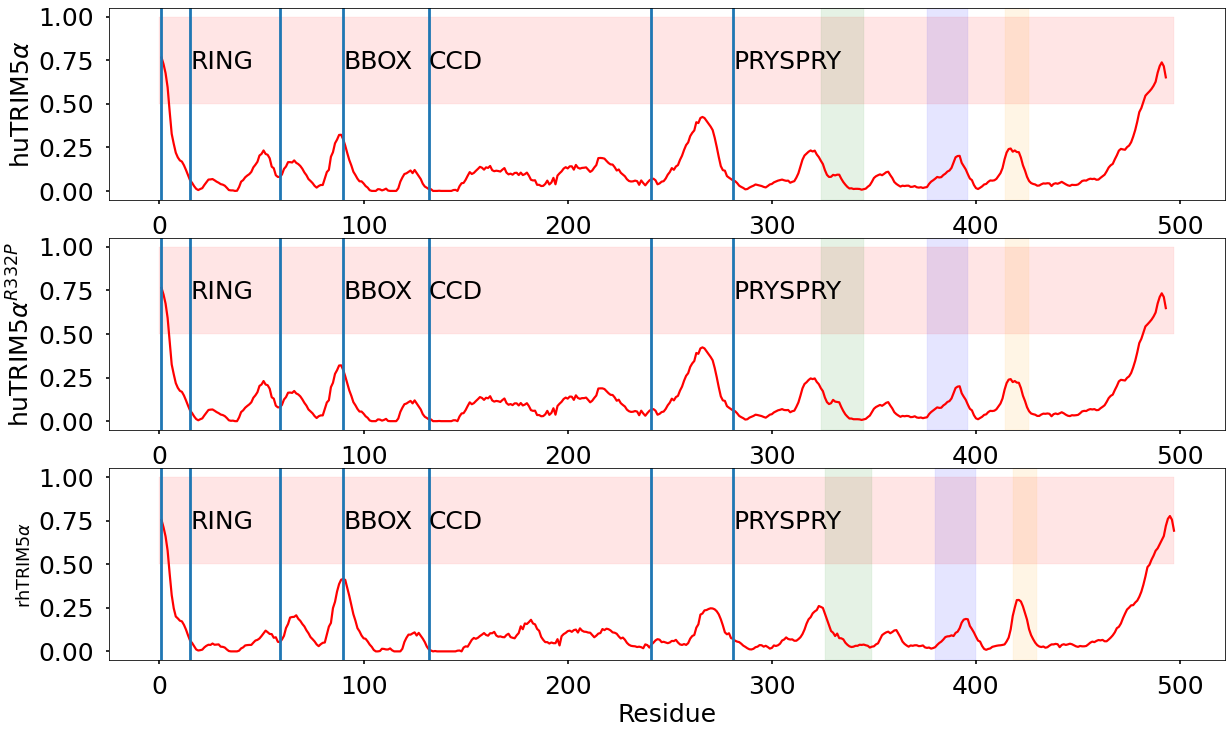

In [14]:

disorderPredictionFiles=glob.glob("disorder_scores-*.csv")
disorderPredictions = []

domain_boundaries=[[1,15,59,90,132,241,281],
                   [1,15,59,90,132,241,281],
                   [1,15,59,90,132,241,281],
                  ]
domain_names=[" ","RING"," ","BBOX","CCD"," ","PRYSPRY"]

figure(figsize = (20,12))

resranges = [
    arange(1,494),
    arange(1,494),
    arange(1,498)    
]
for i in range(len(disorderPredictionFiles)):
    disorderPredictions.append(pd.read_csv(disorderPredictionFiles[i]))
    
    #
    subplot(3,1,i+1)
   # xlim(290,494)
    plot(resranges[i],disorderPredictions[i][" Disorder"],color = "red",linewidth = 2.2)
    #axhline(.5,color = "darkblue",alpha = 0.7)
    fill_between(arange(498), 0.5,1,color = "red",alpha = 0.1)
    _=xticks(fontsize = 25)
    _=yticks(fontsize = 25)
    
    if i == 2:
        axvspan(326,349,color = "green",alpha = 0.1)
        axvspan(380,400,color = "blue",alpha = 0.1)
        axvspan(418,430,color = "orange",alpha = 0.1)
        #axvspan(479,486,color = "red",alpha = 0.1)
        ylabel(r"rhTRIM5$\alpha$")
    else:
        axvspan(324,345,color = "green",alpha = 0.1)
        axvspan(376,396,color = "blue",alpha = 0.1)
        axvspan(414,426,color = "orange",alpha = 0.1)
        #axvspan(475,482,color = "red",alpha = 0.1)
        
        if i == 0:
            ylabel(r"huTRIM5$\alpha$",fontsize = 25)
        if i == 1:
            ylabel(r"huTRIM5$\alpha^{R332P}$",fontsize = 25)
    for j in range(len(domain_boundaries[i])):
        axvline(domain_boundaries[i][j])
        text(domain_boundaries[i][j],.7,s = domain_names[j],fontsize = 25,color = "black")
        
xlabel("Residue", fontsize = 25)    
        
        


Text(0.5, 0, 'Residue')

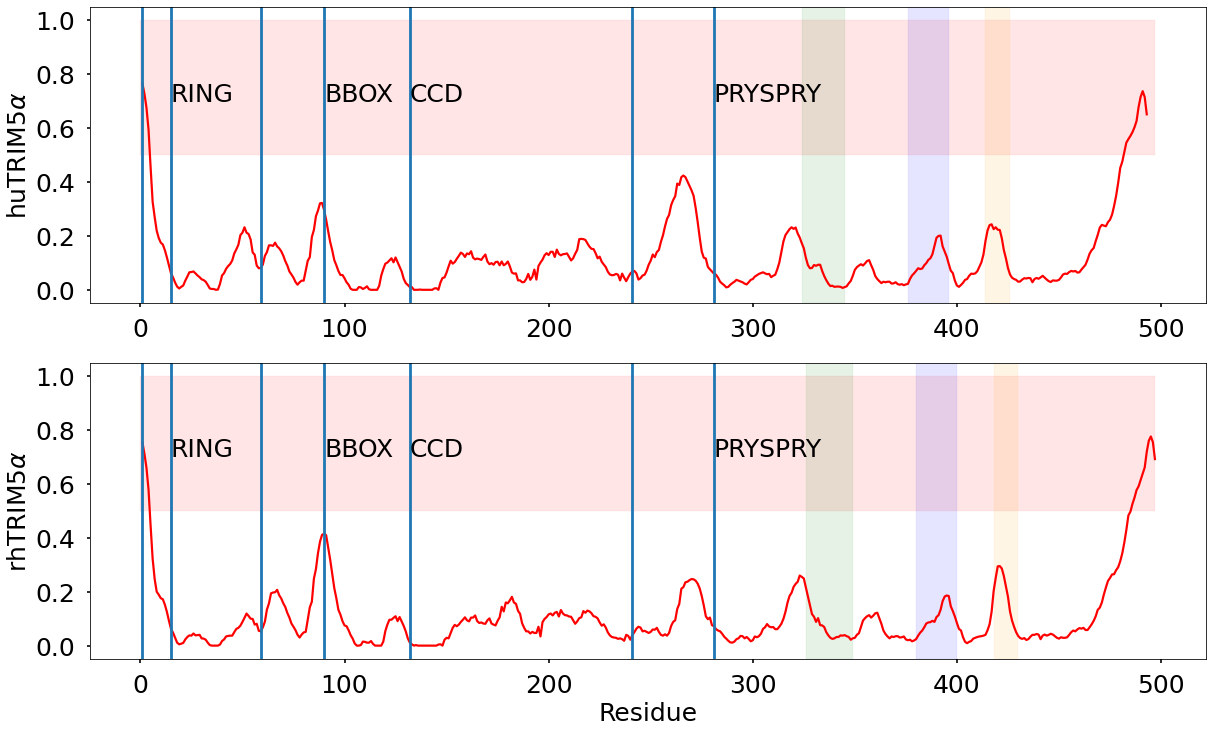

In [15]:

disorderPredictionFiles=glob.glob("disorder_scores-*.csv")
disorderPredictionFiles=[disorderPredictionFiles[0],disorderPredictionFiles[2]]
disorderPredictions = []

domain_boundaries=[[1,15,59,90,132,241,281],
                   #[1,15,59,90,132,241,281],
                   [1,15,59,90,132,241,281],
                  ]
domain_names=[" ","RING"," ","BBOX","CCD"," ","PRYSPRY"]

figure(figsize = (20,12))

resranges = [
    arange(1,494),
    #arange(1,494),
    arange(1,498)    
]
for i in range(len(disorderPredictionFiles)):
    disorderPredictions.append(pd.read_csv(disorderPredictionFiles[i]))
    
    #
    subplot(2,1,i+1)
   # xlim(290,494)
    plot(resranges[i],disorderPredictions[i][" Disorder"],color = "red",linewidth = 2.2)
    #axhline(.5,color = "darkblue",alpha = 0.7)
    fill_between(arange(498), 0.5,1,color = "red",alpha = 0.1)
    _=xticks(fontsize = 25)
    _=yticks(fontsize = 25)
    
    if i == 1:
        axvspan(326,349,color = "green",alpha = 0.1)
        axvspan(380,400,color = "blue",alpha = 0.1)
        axvspan(418,430,color = "orange",alpha = 0.1)
        #axvspan(479,486,color = "red",alpha = 0.1)
        ylabel(r"rhTRIM5$\alpha$", fontsize = 25)
    else:
        axvspan(324,345,color = "green",alpha = 0.1)
        axvspan(376,396,color = "blue",alpha = 0.1)
        axvspan(414,426,color = "orange",alpha = 0.1)
        #axvspan(475,482,color = "red",alpha = 0.1)
        
        if i == 0:
            ylabel(r"huTRIM5$\alpha$",fontsize = 25)
        #if i == 1:
        #    ylabel(r"huTRIM5$\alpha^{R332P}$",fontsize = 25)
    for j in range(len(domain_boundaries[i])):
        axvline(domain_boundaries[i][j])
        text(domain_boundaries[i][j],.7,s = domain_names[j],fontsize = 25,color = "black")
        
xlabel("Residue", fontsize = 25)    
        
        


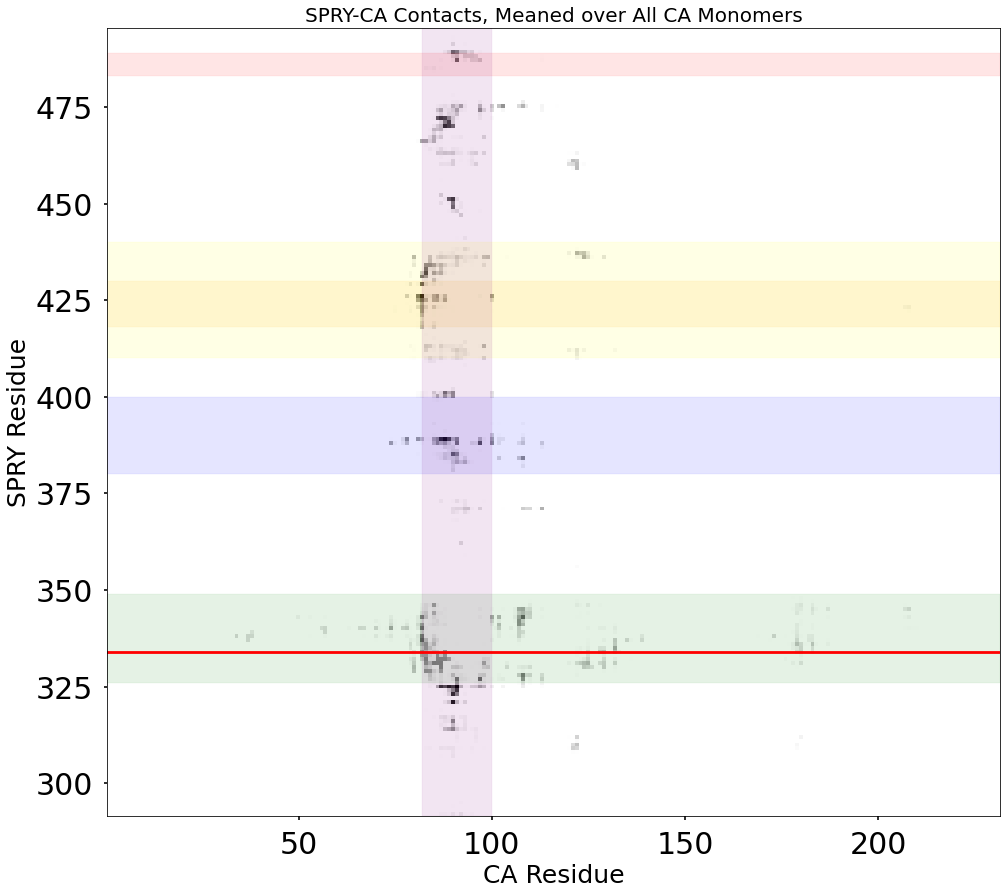

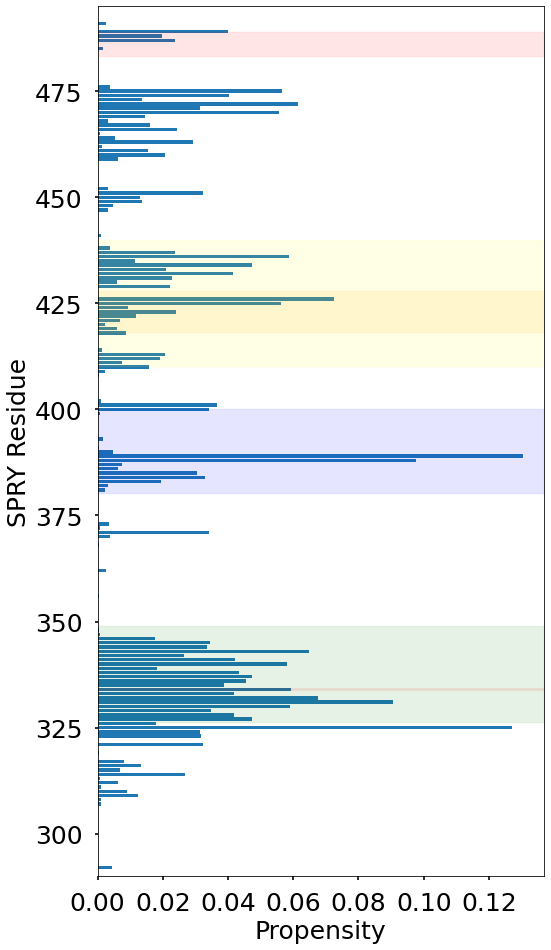

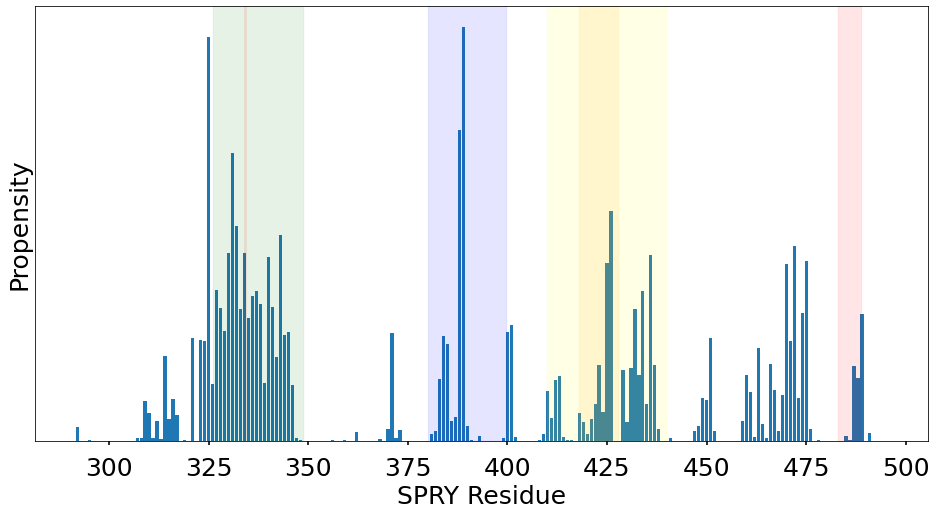

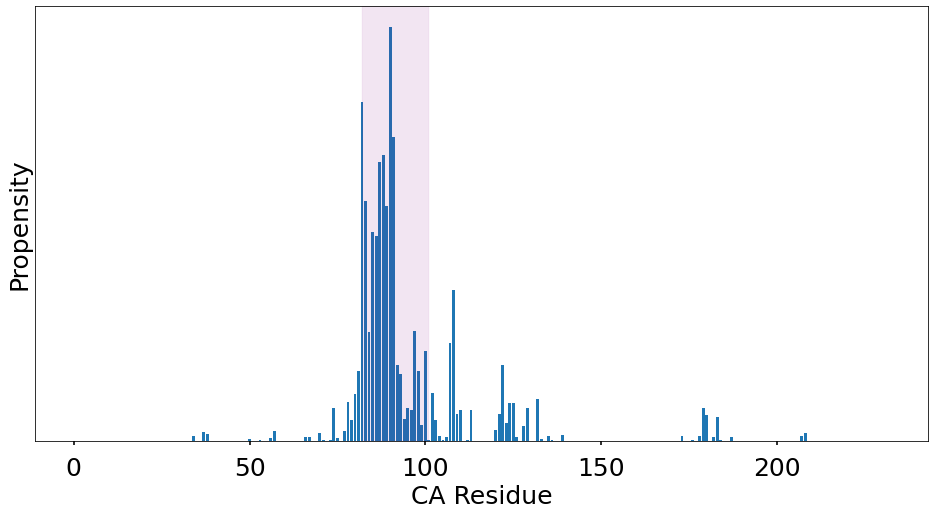

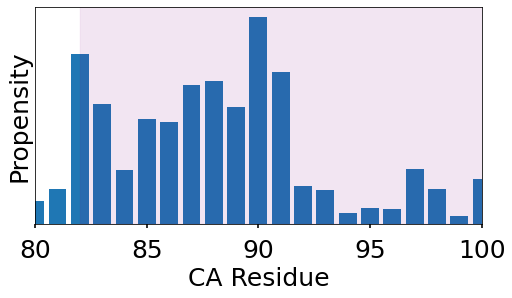

In [16]:
nspry = 493-290 + 1
rhresids = arange(292,496)


contacts_2d=0
for i in range(5):
    contacts_2d+=load("../complex/complexContacts_2d_trajectory"+str(i+1)+".npy")/5

mean_over_cas_spry_contacts=0
for i in range(1,18+1):
    mean_over_cas_spry_contacts+=contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))]
mean_over_cas_spry_contacts/=18

figure(figsize = (16,16))

imshow(mean_over_cas_spry_contacts,origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2))#,vmin = 0,vmax = 1)
title("SPRY-CA Contacts, Meaned over All CA Monomers",fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)


axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(418,430,color = "orange",alpha = 0.1)
axhspan(410,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)


axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)


xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)
show()



figure(figsize = (8,16))
barh(rhresids,sum(mean_over_cas_spry_contacts,axis=1))

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(418,428,color = "orange",alpha = 0.1)
axhspan(410,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)


axhline(334,color = "red",alpha = .1)

xlabel("Propensity",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
ylim(290,495)

show()


#                 Sideways spry contacts
figure(figsize = (16,8))
bar(rhresids,sum(mean_over_cas_spry_contacts,axis=1))

axvspan(326,349,color = "green",alpha = 0.1)
axvspan(380,400,color = "blue",alpha = 0.1)
axvspan(418,428,color = "orange",alpha = 0.1)
axvspan(410,440,color = "yellow",alpha = 0.1)
axvspan(483,489,color = "red",alpha = 0.1)


axvline(334,color = "red",alpha = .1)

ylabel("Propensity",fontsize = 25)
xlabel("SPRY Residue",fontsize = 25)
_=xticks(fontsize = 25)
_=yticks([],fontsize = 25)

#xlim(320,350)

show()

figure(figsize = (16,8))
bar(arange(1,232),sum(mean_over_cas_spry_contacts,axis=0))
#axhspan(326,349,color = "green",alpha = 0.1)
#axhspan(380,400,color = "blue",alpha = 0.1)
#axhspan(418,430,color = "orange",alpha = 0.1) axhspan(410,440,color = "yellow",alpha = 0.1)
#axhspan(483,489,color = "red",alpha = 0.1)
ylabel("Propensity",fontsize = 25)
xlabel("CA Residue",fontsize = 25)
_=xticks(fontsize = 25)
_=yticks([],fontsize = 25)
#ylim(290,493)
axvspan(82,101,color = "purple",alpha = 0.1)

#xlim(81,102)

show()
figure(figsize = (8,4))
bar(arange(1,232),sum(mean_over_cas_spry_contacts,axis=0))
#axhspan(326,349,color = "green",alpha = 0.1)
#axhspan(380,400,color = "blue",alpha = 0.1)
#axhspan(418,430,color = "orange",alpha = 0.1) axhspan(410,440,color = "yellow",alpha = 0.1)
#axhspan(483,489,color = "red",alpha = 0.1)
ylabel("Propensity",fontsize = 25)
xlabel("CA Residue",fontsize = 25)
_=xticks(arange(80,101,5),fontsize = 25)
_=yticks([],fontsize = 25)
#ylim(290,493)
axvspan(82,101,color = "purple",alpha = 0.1)

xlim(80,100)

show()